# 📌 **IMPORTANT: READ FIRST**


---


## 🎯 **Quick Start Guide**


### **Running on Google Colab** (Judges Start Here)


1. **Download Required Files**:


   - 📦 [50 Holdout Test Images (~15MB)](https://drive.google.com/drive/folders/1PGVVcsdHUtQS2D9Kn8PzY0bQQ_xd6_Sp?usp=drive_link)


   - 🏋️ [Pre-Trained Models (best.pt + best.onnx)](https://drive.google.com/drive/folders/1T_U_RAqzdC42yPsJ-NelLuODtkuamvX-?usp=drive_link) *(optional, skip training)*


   - ⚙️ [Config Files](https://drive.google.com/drive/folders/1_x5Z1ufyNnvTqM68pewNqe2k4FitSZhB?usp=sharing) (`class_mapping.json`)


   - ✅ These Google Drive links are the same ones listed in the README. Download from whichever you opened first (no need to download twice).


2. **Upload to Colab (same structure as Kaggle)**:


   - Images → `/content/data/`


   - Models → `/content/runs/train/weights/` *(place `best.pt` + `best.onnx` here)*


   - Config → `/content/config/` *(place `class_mapping.json` here)*


3. **Run Notebook**:


   - **Inference Only (Judges)**: run **CELL 1 → CELL 5 → CELL 6 → CELL 7**


   - **Full Pipeline (training + inference)**: run **CELL 1 → CELL 6** sequentially (then **CELL 7** for summary, **CELL 8** for ZIP)


   - **Note (feasibility)**: For full training, Kaggle is recommended to avoid downloading/uploading the large RPC dataset to Google Drive.


---


### **Running on Kaggle** (Original Development Platform)


- ✅ Dataset is pre-loaded at `/kaggle/input/retail-product-checkout-dataset/`


- ✅ No external downloads needed for the full pipeline


- ✅ Recommended platform for the **full notebook** (training + export + inference + KPIs)


- ✅ Run **CELL 1 → CELL 6** sequentially (then **CELL 7** for summary, **CELL 8** for ZIP)


---


### ⚠️ **Platform Notes**


This notebook **automatically detects** whether it's running on:


- 🟦 **Kaggle** (uses `/kaggle/working/`)


- 🟨 **Google Colab** (uses `/content/`)


- 🟩 **Local** (uses current working directory)




**No manual path changes needed** — just run the notebook with the same folder layout shown above.


---

---
## Environment Setup

**Purpose**: Install dependencies, detect platform (Kaggle/Colab), and create workspace structure.

**Duration**: ~30-60 seconds

**What it does**:
- Installs required packages (`ultralytics`, `onnxruntime`, `albumentations`, `pyyaml`)
- Detects execution environment and sets appropriate paths
- Verifies GPU availability (optional but recommended)
- Creates directory structure for dataset, outputs, and configurations

---

---


## 🔧 **IMPORTANT: Google Colab Setup Instructions**




If you're running this notebook on **Google Colab**, follow the same folder structure as Kaggle under `/content/`.



### **Option 1: Use Full Dataset from Google Drive (Recommended for Training)**


1. **Download RPC Dataset from Kaggle**:

   - https://www.kaggle.com/datasets/diyer22/retail-product-checkout-dataset

   - Download and unzip to get: `train2019/`, `val2019/`, `test2019/` and the COCO JSON files

2. **Upload to Google Drive**:

   - Create folder: `My Drive/RPC_Dataset/`

   - Upload the dataset so it looks like:

     ```

     My Drive/RPC_Dataset/

     ├── train2019/

     ├── val2019/

     ├── test2019/

     ├── instances_train2019.json  (or train2019.json)

     ├── instances_val2019.json

     └── instances_test2019.json

     ```

3. **Run CELL 1**:

   - The notebook will mount Google Drive and automatically use `/content/drive/MyDrive/RPC_Dataset/` if it exists.

4. **Train + Inference**:

   - Run **CELL 2 → CELL 6** sequentially (CELL 4 is training, CELL 5 is ONNX export + inference, CELL 6 is KPIs). Use **CELL 7** for summary and **CELL 8** to create the ZIP (optional).



### **Option 2: Inference Only (Skip Training)**


If you only want to run **inference + KPI computation** (judges path):

1. Download pre-trained models: [Google Drive - Trained Models](https://drive.google.com/drive/folders/1T_U_RAqzdC42yPsJ-NelLuODtkuamvX-?usp=drive_link)

2. Download 50 test images: [Google Drive - Holdout Images](https://drive.google.com/drive/folders/1PGVVcsdHUtQS2D9Kn8PzY0bQQ_xd6_Sp?usp=drive_link)

3. Download config: [Google Drive - Config Files](https://drive.google.com/drive/folders/1_x5Z1ufyNnvTqM68pewNqe2k4FitSZhB?usp=sharing) (`class_mapping.json`)

4. Upload to Colab:

   - `best.pt` + `best.onnx` → `/content/runs/train/weights/`

   - `class_mapping.json` → `/content/config/`

   - 50 images → `/content/data/`

5. Run **CELL 1 → CELL 5 → CELL 6 → CELL 7** (skip training cells).



---



### ⚠️ **For Kaggle Users**



No extra setup needed — the RPC dataset is pre-loaded at `/kaggle/input/retail-product-checkout-dataset/`.



---

# 🛒 AI for Competitive Shelf Analysis from Photos


## **End-to-End Retail Product Detection Pipeline**


---


### 📋 **Project Overview**


This notebook implements a complete AI system for analyzing retail shelf images to compute competitive KPIs including:

- **Product Detection**: YOLOv8n model trained on 15 product classes

- **Brand Analytics**: facings count, market share, shelf share percentages

- **Availability Metrics**: out-of-stock rate, in-stock availability

- **Competitive Intelligence**: market leadership, dominance ratios



---



### 📊 **Dataset**

**Source**: [Retail Product Checkout (RPC) Dataset](https://www.kaggle.com/datasets/diyer22/retail-product-checkout-dataset)

- **Total Classes**: 200 product categories

- **Filtered Classes**: Top 15 by frequency

- **Holdout Test Set**: 50 images for final evaluation



---



### 🎯 **Methodology**

1. **Data Preparation**: COCO format → YOLO format with class filtering

2. **Model Training**: YOLOv8n with retail-optimized hyperparameters

3. **Inference**: ONNX export for CPU-compatible deployment

4. **KPI Computation**: simulated brand assignment + per-shelf and aggregate metrics



---



### 🚀 **How to Run**



#### **Judges / Inference-Only (Colab or Kaggle)**

1. Ensure you have:

   - `runs/train/weights/best.pt` and `runs/train/weights/best.onnx`

   - `config/class_mapping.json`

   - Holdout images available (Colab: upload to `/content/data/`; Kaggle: already available in the RPC dataset)

2. Run **CELL 1 → CELL 5 → CELL 6 → CELL 7**.



#### **Full Pipeline (Training + Inference)**

- Run **CELL 1 → CELL 6** in order (CELL 4 trains). Use **CELL 7** for summary and **CELL 8** for the ZIP package if needed.



---



### 📦 **Requirements**

- Python 3.8+

- CUDA-capable GPU (optional; CPU inference supported via ONNX)

- Libraries: `ultralytics`, `onnxruntime`, `opencv-python`, `pandas`, `matplotlib`



---



### 📝 **Authors**

**Team**: Khaled Nabil  

**Date**: February 2026  

**Hackathon**: AI for Competitive Shelf Analysis Challenge



---

In [ ]:
# ============================================================================
# CELL 1: ENVIRONMENT SETUP & DEPENDENCY INSTALLATION
# ============================================================================

import sys
import subprocess
import os
from pathlib import Path

print("=" * 80)
print("CELL 1: ENVIRONMENT SETUP")
print("=" * 80)

# PLATFORM DETECTION (Kaggle vs Google Colab)
# ============================================================================
print("\n[1/6] Detecting Platform...")

if 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
    PLATFORM = 'Kaggle'
    WORKSPACE_ROOT = Path('/kaggle/working')
    INPUT_ROOT = Path('/kaggle/input/retail-product-checkout-dataset')
    print(f"  Platform:           {PLATFORM}")
    print(f"  Workspace Root:     {WORKSPACE_ROOT}")
    print(f"  Input Root:         {INPUT_ROOT}")
    
elif 'COLAB_GPU' in os.environ or os.path.exists('/content'):
    PLATFORM = 'Colab'
    WORKSPACE_ROOT = Path('/content')
    
    print(f"  Platform:           {PLATFORM}")
    print(f"  Workspace Root:     {WORKSPACE_ROOT}")
    
    # Mount Google Drive for dataset access
    print("\n  🔗 Mounting Google Drive...")
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        
        # Check for RPC dataset in Google Drive
        DRIVE_DATASET_PATH = Path('/content/drive/MyDrive/RPC_Dataset')
        if DRIVE_DATASET_PATH.exists():
            INPUT_ROOT = DRIVE_DATASET_PATH
            print(f"  ✅ Found RPC Dataset in Google Drive!")
            print(f"  Input Root:         {INPUT_ROOT}")
        else:
            # Fallback to local /content/data/ (inference only mode)
            INPUT_ROOT = WORKSPACE_ROOT / 'data'
            print(f"  ⚠️  RPC Dataset not found in Google Drive at: {DRIVE_DATASET_PATH}")
            print(f"  ⚠️  Using local data folder (inference-only mode)")
            print(f"  Input Root:         {INPUT_ROOT}")
            print(f"\n  💡 To run training, upload RPC dataset to: {DRIVE_DATASET_PATH}")
    except Exception as e:
        INPUT_ROOT = WORKSPACE_ROOT / 'data'
        print(f"  ⚠️  Could not mount Google Drive: {e}")
        print(f"  Input Root:         {INPUT_ROOT} (inference-only mode)")
        
else:
    PLATFORM = 'Local'
    WORKSPACE_ROOT = Path.cwd()
    INPUT_ROOT = WORKSPACE_ROOT / 'data'
    print(f"  Platform:           {PLATFORM}")
    print(f"  Workspace Root:     {WORKSPACE_ROOT}")
    print(f"  Input Root:         {INPUT_ROOT}")

# INSTALL REQUIRED PACKAGES
# ============================================================================
print("\n[2/6] Installing Dependencies...")

packages = [
    'ultralytics',
    'onnxruntime',
    'albumentations',
    'pyyaml',
]

for pkg in packages:
    print(f"  Installing {pkg}...")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

print("✅ All packages installed successfully.")

# IMPORT CORE LIBRARIES
# ============================================================================
print("\n[3/6] Importing Libraries...")

import json
import shutil
import random
from pathlib import Path
from datetime import datetime
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

from ultralytics import YOLO
import onnxruntime as ort
import yaml

from tqdm.auto import tqdm

print("✅ All imports successful.")

# ENVIRONMENT DIAGNOSTICS
# ============================================================================
print("\n[4/6] Environment Diagnostics:")
print(f"  Python Version:     {sys.version.split()[0]}")
print(f"  NumPy Version:      {np.__version__}")
print(f"  OpenCV Version:     {cv2.__version__}")

try:
    from ultralytics import __version__ as ultralytics_version
    print(f"  Ultralytics:        {ultralytics_version}")
except:
    print(f"  Ultralytics:        (installed)")

try:
    import torch
    gpu_available = torch.cuda.is_available()
    if gpu_available:
        gpu_name = torch.cuda.get_device_name(0)
        gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f"  GPU Available:      ✅ {gpu_name} ({gpu_memory:.0f}GB)")
    else:
        print(f"  GPU Available:      ❌ (CPU mode - training will be slower)")
except Exception as e:
    print(f"  GPU Available:      ❌ PyTorch not found")

# WORKSPACE SETUP
# ============================================================================
print("\n[5/6] Setting Up Workspace...")

PROJECT_DIRS = {
    'dataset': WORKSPACE_ROOT / 'rpc_yolo_filtered',
    'holdout': WORKSPACE_ROOT / 'data',  # Always store holdout/test images here
    'runs': WORKSPACE_ROOT / 'runs',
    'output': WORKSPACE_ROOT / 'output',
    'config': WORKSPACE_ROOT / 'config',
}

for name, path in PROJECT_DIRS.items():
    path.mkdir(parents=True, exist_ok=True)
    print(f"  Created: {path}")

# DATASET AVAILABILITY CHECK
# ============================================================================
print("\n[6/6] Checking Dataset Availability...")

# Check for required JSON files
required_files = [
    INPUT_ROOT / 'instances_train2019.json',
    INPUT_ROOT / 'instances_val2019.json',
    INPUT_ROOT / 'instances_test2019.json',
]

missing_files = [f for f in required_files if not f.exists()]

if missing_files:
    print(f"  ⚠️  WARNING: RPC Dataset files not found!")
    print(f"  Missing files:")
    for f in missing_files:
        print(f"    - {f}")
    print(f"\n  ❌ Training pipeline (Cells 2-4) will NOT work without full dataset.")
    print(f"  ✅ Inference pipeline (Cells 5-7) can still work with pre-trained models.")
    if PLATFORM == 'Colab':
        print(f"\n  💡 Solution: Upload RPC dataset to Google Drive at:")
        print(f"     /content/drive/MyDrive/RPC_Dataset/")
else:
    print(f"  ✅ All dataset files found!")
    print(f"  ✅ Ready for full training + inference pipeline.")

print("\n" + "=" * 80)
print("✅ ENVIRONMENT SETUP COMPLETE")
print("=" * 80)

# ═══════════════════════════════════════════════════════════════════════════
# GLOBAL CONFIGURATION (TUNABLE HYPERPARAMETERS)
# ═══════════════════════════════════════════════════════════════════════════

# Dataset Configuration
NUM_CLASSES_FILTERED = 15      # Top K classes by frequency
SAMPLE_RATIO = 0.30             # 30% of filtered data
HOLDOUT_SIZE = 50               # Images for final testing

# Training Configuration (Optimized for Kaggle T4 GPU)
TRAIN_EPOCHS = 30               # Sufficient for filtered dataset
TRAIN_BATCH = 16                # ✅ Kaggle GPU-friendly (your recommendation)
TRAIN_IMGSZ = 416               # Faster than 640, sufficient for 15 classes
TRAIN_PATIENCE = 10             # Early stopping

# Inference Configuration
INFERENCE_CONF = 0.25           # Confidence threshold
INFERENCE_IOU = 0.45            # NMS IoU threshold

print(f"  Classes:            {NUM_CLASSES_FILTERED} (filtered from 200)")
print(f"  Sampling:           {SAMPLE_RATIO*100:.0f}% of filtered data")
print(f"  Batch Size:         {TRAIN_BATCH} (GPU-optimized)")
print(f"  Image Size:         {TRAIN_IMGSZ}x{TRAIN_IMGSZ}")
print(f"  Epochs:             {TRAIN_EPOCHS}")

print("\n✅ SETUP COMPLETE. Ready for Class Filtering & Data Preparation.")
print("=" * 80)

CELL 1: ENVIRONMENT SETUP

[1/6] Detecting Platform...
  Platform:           Kaggle
  Workspace Root:     /kaggle/working
  Input Root:         /kaggle/input/retail-product-checkout-dataset

[2/6] Installing Dependencies...
  Installing ultralytics...
  Installing onnxruntime...
  Installing albumentations...
  Installing pyyaml...
✅ All packages installed successfully.

[3/6] Importing Libraries...
✅ All imports successful.

[4/6] Environment Diagnostics:
  Python Version:     3.12.12
  NumPy Version:      2.0.2
  OpenCV Version:     4.12.0
  Ultralytics:        8.4.12
  GPU Available:      ✅ Tesla P100-PCIE-16GB (17GB)

[5/6] Setting Up Workspace...
  Created: /kaggle/working/rpc_yolo_filtered
  Created: /kaggle/working/data
  Created: /kaggle/working/runs
  Created: /kaggle/working/output
  Created: /kaggle/working/config

[6/6] Checking Dataset Availability...
  ✅ All dataset files found!
  ✅ Ready for full training + inference pipeline.

✅ ENVIRONMENT SETUP COMPLETE
  Classes:    

---
## 📊 Class Frequency Analysis

**Purpose:** Analyzes the RPC dataset (200 classes) and selects the **top 15 most frequent classes** for our prototype.

**Duration:** ~10 seconds

**What it does:**
- Parses COCO annotation files (`instances_train2019.json` or `train2019.json`)
- Counts annotation frequency for all classes
- Selects top 15 classes
- Maps RPC class IDs → YOLO class IDs (0–14)
- Exports `filtered_classes.yaml` and `class_mapping.json`

**Why this matters:** Training on 15 classes is much faster than 200 while keeping strong performance for this demo.

---

CELL 2: CLASS FREQUENCY ANALYSIS & SELECTION

[1/4] Loading RPC Annotations...
  Found: /kaggle/input/retail-product-checkout-dataset/instances_train2019.json
  Categories: 200
  Annotations: 53,739
✅ Annotations loaded.

[2/4] Analyzing Class Frequency...
  Total annotations across all classes: 53,739
  Classes with >500 instances: 5
  Classes with >1000 instances: 0
✅ Frequency analysis complete.

[3/4] Top 15 Most Frequent Classes:

  Rank   Class ID   Count    Class Name                                        
  ────────────────────────────────────────────────────────────────────────────
  1      196        640      196_stationery
  2      131        640      131_chocolate
  3      190        640      190_tissue
  4      197        640      197_stationery
  5      173        640      173_personal_hygiene
  6      124        480      124_chocolate
  7      172        320      172_personal_hygiene
  8      177        320      177_tissue
  9      148        320      148_candy
  10    

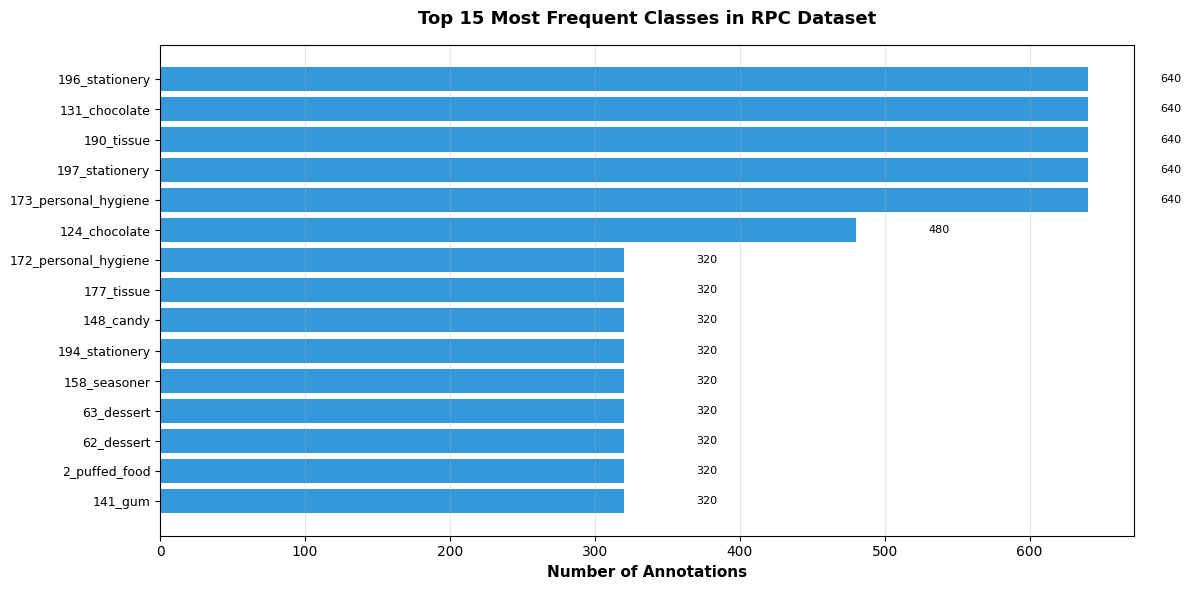

✅ Visualization complete.

✅ CLASS SELECTION COMPLETE. Ready for Data Preparation.


In [ ]:
# ============================================================================
# CELL 2: CLASS FREQUENCY ANALYSIS & TOP-15 SELECTION
# ============================================================================
# Purpose: Analyze RPC dataset and select most frequent 15 classes
# Expected Duration: 10-15 seconds
# ============================================================================

print("=" * 80)
print("CELL 2: CLASS FREQUENCY ANALYSIS & SELECTION")
print("=" * 80)

# 1. LOAD RPC ANNOTATIONS
# ============================================================================
print("\n[1/4] Loading RPC Annotations...")

# Use dataset root detected in CELL 1; fall back to common locations if needed
if 'INPUT_ROOT' in globals():
    DATASET_ROOT = INPUT_ROOT
else:
    kaggle_default = Path('/kaggle/input/retail-product-checkout-dataset')
    drive_default = Path('/content/drive/MyDrive/RPC_Dataset')
    DATASET_ROOT = kaggle_default if kaggle_default.exists() else drive_default

TRAIN_JSON = DATASET_ROOT / 'instances_train2019.json'

# Verify file exists
if not TRAIN_JSON.exists():
    print(f"❌ ERROR: Annotation file not found at {TRAIN_JSON}")
    print(f"   Available files in dataset root:")
    for f in DATASET_ROOT.glob('*.json'):
        print(f"     - {f.name}")
    raise FileNotFoundError(f"Missing: {TRAIN_JSON}")

print(f"  Found: {TRAIN_JSON}")

# Load COCO JSON
with open(TRAIN_JSON, 'r', encoding='utf-8') as f:
    coco_data = json.load(f)

num_categories = len(coco_data['categories'])
num_annotations = len(coco_data['annotations'])

print(f"  Categories: {num_categories}")
print(f"  Annotations: {num_annotations:,}")
print("✅ Annotations loaded.")

# 2. ANALYZE CLASS FREQUENCY
# ============================================================================
print("\n[2/4] Analyzing Class Frequency...")

# Count annotations per class (NOT images, but bounding boxes)
class_counts = defaultdict(int)
for ann in coco_data['annotations']:
    class_counts[ann['category_id']] += 1

# Build class name lookup
class_id_to_name = {cat['id']: cat['name'] for cat in coco_data['categories']}

print(f"  Total annotations across all classes: {sum(class_counts.values()):,}")
print(f"  Classes with >500 instances: {sum(1 for c in class_counts.values() if c > 500)}")
print(f"  Classes with >1000 instances: {sum(1 for c in class_counts.values() if c > 1000)}")
print("✅ Frequency analysis complete.")

# 3. SELECT TOP K CLASSES
# ============================================================================
print(f"\n[3/4] Top {NUM_CLASSES_FILTERED} Most Frequent Classes:")

# Sort by count (descending)
sorted_classes = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
top_k_classes = sorted_classes[:NUM_CLASSES_FILTERED]

# Display table
print(f"\n  {'Rank':<6} {'Class ID':<10} {'Count':<8} {'Class Name':<50}")
print(f"  {'─' * 76}")

total_filtered_annotations = 0
for rank, (class_id, count) in enumerate(top_k_classes, start=1):
    class_name = class_id_to_name[class_id]
    # Truncate long names for display
    display_name = class_name if len(class_name) <= 47 else class_name[:44] + "..."
    print(f"  {rank:<6} {class_id:<10} {count:<8,} {display_name}")
    total_filtered_annotations += count

percentage = (total_filtered_annotations / sum(class_counts.values())) * 100
print(f"\n  Total annotations in filtered set: {total_filtered_annotations:,} ({percentage:.0f}% of dataset)")
print(f"✅ Top {NUM_CLASSES_FILTERED} classes selected.")

# 4. CREATE FILTERED CLASS MAPPING
# ============================================================================
print("\n[4/4] Saving Configuration...")

# Extract class IDs
SELECTED_CLASS_IDS = {class_id for class_id, _ in top_k_classes}

# Create YOLO class mapping (RPC ID → YOLO Index 0-14)
# Sort by original RPC ID for consistency
selected_categories = [cat for cat in coco_data['categories'] if cat['id'] in SELECTED_CLASS_IDS]
selected_categories.sort(key=lambda x: x['id'])  # Maintain deterministic order

# Build mappings
RPC_TO_YOLO = {cat['id']: idx for idx, cat in enumerate(selected_categories)}
YOLO_CLASS_NAMES = {idx: cat['name'] for idx, cat in enumerate(selected_categories)}

# Save as YAML (for YOLO training)
yaml_config = {
    'nc': len(YOLO_CLASS_NAMES),
    'names': YOLO_CLASS_NAMES,
    'source': 'RPC Dataset (Top 15 Classes)',
    'created': datetime.now().isoformat()
}

yaml_path = PROJECT_DIRS['config'] / 'filtered_classes.yaml'
with open(yaml_path, 'w', encoding='utf-8') as f:
    yaml.dump(yaml_config, f, allow_unicode=True, sort_keys=False)

print(f"  Saved: {yaml_path}")

# Save detailed mapping as JSON (for inference)
json_config = {
    'num_classes': len(YOLO_CLASS_NAMES),
    'rpc_to_yolo': RPC_TO_YOLO,
    'yolo_names': YOLO_CLASS_NAMES,
    'selected_rpc_ids': list(SELECTED_CLASS_IDS),
    'class_frequencies': {class_id: class_counts[class_id] for class_id in SELECTED_CLASS_IDS},
    'total_annotations': total_filtered_annotations,
    'created': datetime.now().isoformat()
}

json_path = PROJECT_DIRS['config'] / 'class_mapping.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(json_config, f, indent=2, ensure_ascii=False)

print(f"  Saved: {json_path}")
print("✅ Configuration saved.")

# 5. VISUAL SUMMARY (Optional - helps verify selection)
# ============================================================================
print("\n[5/5] Generating Frequency Plot...")

fig, ax = plt.subplots(figsize=(12, 6))

# Plot top 15 classes
classes_display = [class_id_to_name[cid][:30] for cid, _ in top_k_classes]  # Truncate names
counts_display = [count for _, count in top_k_classes]

bars = ax.barh(range(len(classes_display)), counts_display, color='#3498db')
ax.set_yticks(range(len(classes_display)))
ax.set_yticklabels(classes_display, fontsize=9)
ax.set_xlabel('Number of Annotations', fontsize=11, fontweight='bold')
ax.set_title(f'Top {NUM_CLASSES_FILTERED} Most Frequent Classes in RPC Dataset', 
             fontsize=13, fontweight='bold', pad=15)
ax.invert_yaxis()  # Highest frequency at top
ax.grid(axis='x', alpha=0.3)

# Add count labels on bars
for i, (bar, count) in enumerate(zip(bars, counts_display)):
    ax.text(count + 50, bar.get_y() + bar.get_height()/2, 
            f'{count:,}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print("✅ Visualization complete.")

print("\n" + "=" * 80)
print("✅ CLASS SELECTION COMPLETE. Ready for Data Preparation.")
print("=" * 80)

---
## 🔄 COCO-to-YOLO Conversion

**Purpose:** Converts filtered RPC annotations from COCO JSON format to YOLO TXT format with **direct file copying** (no symlinks).

**Duration:** ~3–5 minutes

**What it does:**
- Validates images with PIL (catches corrupt files)
- Copies images using `shutil.copy2()` (avoids Kaggle read-only issues)
- Converts bounding boxes: COCO `[x, y, w, h]` → YOLO `[x_center, y_center, w, h]` (normalized)
- Samples a subset for faster training
- Creates a YOLO dataset folder: `rpc_yolo_filtered/` with `train/` + `val/` and a `dataset.yaml`

**Output (workspace):**
- `rpc_yolo_filtered/` (YOLO dataset)
- Holdout images are read from `PROJECT_DIRS['holdout']` (Colab judges: `/content/data/`)

---

In [ ]:
# ============================================================================
# CELL 3: FILTERED COCO-TO-YOLO CONVERSION (NO SYMLINKS)
# ============================================================================
# Purpose: Convert 15 selected classes to YOLO format with direct file copy
# Expected Duration: 3-4 minutes
# ============================================================================

print("=" * 80)
print("CELL 3: FILTERED COCO-TO-YOLO CONVERSION")
print("=" * 80)

# 1. SETUP YOLO DIRECTORY STRUCTURE
# ============================================================================
print("\n[1/7] Setting Up YOLO Directory Structure...")

YOLO_ROOT = PROJECT_DIRS['dataset']
HOLDOUT_ROOT = PROJECT_DIRS['holdout']

for split in ['train', 'val']:
    (YOLO_ROOT / 'images' / split).mkdir(parents=True, exist_ok=True)
    (YOLO_ROOT / 'labels' / split).mkdir(parents=True, exist_ok=True)

print("✅ Directories created.")

# 2. IMAGE VALIDATION HELPER
# ============================================================================
def validate_and_copy_image(src_path, dst_path):
    """
    Validate image and copy to destination.
    Returns True if successful, False if corrupt/invalid.
    """
    try:
        # Validate image can be opened
        with Image.open(src_path) as img:
            img.verify()  # Check header
        
        # Re-open for actual copy (verify() closes file)
        with Image.open(src_path) as img:
            img.load()  # Force decode to catch truncated files
            
            # Size sanity check
            if img.size[0] < 10 or img.size[1] < 10:
                return False
        
        # Copy file
        shutil.copy2(src_path, dst_path)
        return True
        
    except Exception as e:
        return False

# 3. CONVERSION ENGINE
# ============================================================================
def convert_split_to_yolo(name, json_path, img_dir, target_split, exclude_ids=None):
    """
    Convert COCO annotations to YOLO format with filtering and sampling.
    
    Args:
        name: Dataset name (for logging)
        json_path: Path to COCO JSON
        img_dir: Directory containing images
        target_split: 'train' or 'val'
        exclude_ids: Set of image IDs to skip (holdout set)
    
    Returns:
        (processed_count, skipped_count, invalid_count)
    """
    print(f"\n[Processing] {name} → {target_split.upper()}")
    
    # Load COCO JSON
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    # STEP 1: Filter annotations to selected classes
    print(f"  Filtering to {NUM_CLASSES_FILTERED} classes...")
    filtered_anns = [ann for ann in data['annotations'] 
                     if ann['category_id'] in SELECTED_CLASS_IDS]
    
    print(f"  Found {len(filtered_anns):,} annotations in selected classes")
    
    # STEP 2: Get unique image IDs that have filtered annotations
    img_ids_with_anns = set(ann['image_id'] for ann in filtered_anns)
    
    # Filter images to only those with relevant annotations
    filtered_images = [img for img in data['images'] 
                       if img['id'] in img_ids_with_anns]
    
    # STEP 3: Sample images (30%)
    random.seed(42)  # Reproducibility
    original_count = len(filtered_images)
    sample_size = int(original_count * SAMPLE_RATIO)
    sampled_images = random.sample(filtered_images, sample_size)
    
    print(f"  Sampling {SAMPLE_RATIO*100:.0f}% ({len(sampled_images):,} images)...")
    
    # Build image ID set for quick lookup
    sampled_img_ids = {img['id'] for img in sampled_images}
    
    # STEP 4: Index annotations by image_id
    anns_by_img = defaultdict(list)
    for ann in filtered_anns:
        if ann['image_id'] in sampled_img_ids:
            anns_by_img[ann['image_id']].append(ann)
    
    # STEP 5: Process images
    img_output_dir = YOLO_ROOT / 'images' / target_split
    lbl_output_dir = YOLO_ROOT / 'labels' / target_split
    
    processed = 0
    skipped = 0
    invalid = 0
    
    for img_info in tqdm(sampled_images, desc=f"  Converting"):
        img_id = img_info['id']
        
        # Skip if in holdout set
        if exclude_ids and img_id in exclude_ids:
            skipped += 1
            continue
        
        file_name = img_info['file_name']
        img_w = img_info['width']
        img_h = img_info['height']
        
        # Source and destination paths
        src_img = img_dir / file_name
        dst_img = img_output_dir / file_name
        
        # Skip if source doesn't exist
        if not src_img.exists():
            invalid += 1
            continue
        
        # Validate and copy image (NO SYMLINKS!)
        if not dst_img.exists():
            if not validate_and_copy_image(src_img, dst_img):
                invalid += 1
                continue
        
        # Create YOLO label file
        txt_name = Path(file_name).stem + '.txt'
        txt_path = lbl_output_dir / txt_name
        
        with open(txt_path, 'w') as f_txt:
            if img_id in anns_by_img:
                for ann in anns_by_img[img_id]:
                    cat_id = ann['category_id']
                    
                    # Skip if not in our mapping (shouldn't happen after filtering)
                    if cat_id not in RPC_TO_YOLO:
                        continue
                    
                    bbox = ann['bbox']  # [x, y, width, height] in pixels
                    
                    # Convert to YOLO format (normalized center coordinates)
                    x_center = (bbox[0] + bbox[2] / 2.0) / img_w
                    y_center = (bbox[1] + bbox[3] / 2.0) / img_h
                    width = bbox[2] / img_w
                    height = bbox[3] / img_h
                    
                    # Clip to valid range [0, 1]
                    x_center = max(0.0, min(1.0, x_center))
                    y_center = max(0.0, min(1.0, y_center))
                    width = max(0.0, min(1.0, width))
                    height = max(0.0, min(1.0, height))
                    
                    # Get YOLO class index
                    yolo_cls = RPC_TO_YOLO[cat_id]
                    
                    # Write YOLO annotation
                    f_txt.write(f"{yolo_cls} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")
        
        processed += 1
    
    print(f"  ✅ Processed: {processed:,} images | Skipped: {skipped} | Invalid: {invalid}")
    return processed, skipped, invalid

# 4. PROCESS TRAIN2019 → TRAIN
# ============================================================================
print("\n[2/7] Processing train2019 (Single Items) → TRAIN")

TRAIN_JSON = INPUT_ROOT / 'instances_train2019.json'
TRAIN_IMG_DIR = INPUT_ROOT / 'train2019'

train_proc, train_skip, train_invalid = convert_split_to_yolo(
    name='train2019',
    json_path=TRAIN_JSON,
    img_dir=TRAIN_IMG_DIR,
    target_split='train',
    exclude_ids=None
)

# 5. PROCESS TEST2019 → TRAIN (Clutter data)
# ============================================================================
print("\n[3/7] Processing test2019 (Clutter) → TRAIN")

TEST_JSON = INPUT_ROOT / 'instances_test2019.json'
TEST_IMG_DIR = INPUT_ROOT / 'test2019'

test_proc, test_skip, test_invalid = convert_split_to_yolo(
    name='test2019',
    json_path=TEST_JSON,
    img_dir=TEST_IMG_DIR,
    target_split='train',
    exclude_ids=None
)

# 6. SELECT HOLDOUT SET FROM VAL2019
# ============================================================================
print("\n[4/7] Selecting Holdout Set from val2019...")

VAL_JSON = INPUT_ROOT / 'instances_val2019.json'
VAL_IMG_DIR = INPUT_ROOT / 'val2019'

with open(VAL_JSON, 'r', encoding='utf-8') as f:
    val_data = json.load(f)

# Filter to images with selected classes
val_anns = [ann for ann in val_data['annotations'] 
            if ann['category_id'] in SELECTED_CLASS_IDS]
val_img_ids_with_anns = set(ann['image_id'] for ann in val_anns)
val_images_filtered = [img for img in val_data['images'] 
                       if img['id'] in val_img_ids_with_anns]

# Randomly select holdout images
random.seed(42)
holdout_images = random.sample(val_images_filtered, min(HOLDOUT_SIZE, len(val_images_filtered)))
holdout_ids = {img['id'] for img in holdout_images}

print(f"  ✅ Selected {len(holdout_images)} random images for holdout")

# Save holdout IDs to config
holdout_config = {
    'holdout_image_ids': list(holdout_ids),
    'holdout_count': len(holdout_ids),
    'source': 'val2019',
    'created': datetime.now().isoformat()
}

holdout_config_path = PROJECT_DIRS['config'] / 'holdout_ids.json'
with open(holdout_config_path, 'w') as f:
    json.dump(holdout_config, f, indent=2)

print(f"  Holdout IDs saved to config")

# 7. PROCESS VAL2019 → VAL (Exclude holdout)
# ============================================================================
print("\n[5/7] Processing val2019 (Clutter) → VAL")

val_proc, val_skip, val_invalid = convert_split_to_yolo(
    name='val2019',
    json_path=VAL_JSON,
    img_dir=VAL_IMG_DIR,
    target_split='val',
    exclude_ids=holdout_ids  # Exclude holdout images
)

# 8. COPY HOLDOUT IMAGES TO /data/
# ============================================================================
print("\n[6/7] Copying Holdout Images to /data/...")

holdout_copied = 0
for img_info in tqdm(holdout_images, desc="  Copying"):
    src = VAL_IMG_DIR / img_info['file_name']
    dst = HOLDOUT_ROOT / img_info['file_name']
    
    if src.exists() and not dst.exists():
        if validate_and_copy_image(src, dst):
            holdout_copied += 1

print(f"  ✅ Holdout images saved to {HOLDOUT_ROOT}")

# 9. CREATE YOLO DATASET CONFIG
# ============================================================================
print("\n[7/7] Creating YOLO Dataset Config...")

yolo_dataset_config = {
    'path': str(YOLO_ROOT),
    'train': 'images/train',
    'val': 'images/val',
    'nc': len(YOLO_CLASS_NAMES),
    'names': YOLO_CLASS_NAMES
}

config_path = YOLO_ROOT / 'dataset.yaml'
with open(config_path, 'w', encoding='utf-8') as f:
    yaml.dump(yolo_dataset_config, f, allow_unicode=True, sort_keys=False)

print(f"  ✅ Config saved: {config_path}")

# 10. VALIDATION SUMMARY
# ============================================================================
print("\n" + "=" * 80)
print("VALIDATION SUMMARY")
print("=" * 80)

train_imgs = len(list((YOLO_ROOT / 'images' / 'train').glob('*.jpg')))
train_lbls = len(list((YOLO_ROOT / 'labels' / 'train').glob('*.txt')))
val_imgs = len(list((YOLO_ROOT / 'images' / 'val').glob('*.jpg')))
val_lbls = len(list((YOLO_ROOT / 'labels' / 'val').glob('*.txt')))
holdout_imgs = len(list(HOLDOUT_ROOT.glob('*.jpg')))

print(f"  Training:   {train_imgs:,} images | {train_lbls:,} labels")
print(f"  Validation: {val_imgs:,} images | {val_lbls:,} labels")
print(f"  Holdout:    {holdout_imgs} images")
print(f"  Total:      {train_imgs + val_imgs + holdout_imgs:,} images processed")

# Check for mismatches
if train_imgs != train_lbls:
    print(f"  ⚠️  WARNING: Train image/label mismatch ({train_imgs} vs {train_lbls})")
if val_imgs != val_lbls:
    print(f"  ⚠️  WARNING: Val image/label mismatch ({val_imgs} vs {val_lbls})")

if train_imgs == train_lbls and val_imgs == val_lbls:
    print("\n✅ All validation checks passed.")

# Sample label inspection
if train_lbls > 0:
    sample_label = list((YOLO_ROOT / 'labels' / 'train').glob('*.txt'))[0]
    print(f"\nSample Label ({sample_label.name}):")
    with open(sample_label, 'r') as f:
        lines = f.readlines()[:3]
        for line in lines:
            parts = line.strip().split()
            if len(parts) == 5:
                cls_idx = int(parts[0])
                cls_name = YOLO_CLASS_NAMES.get(cls_idx, 'Unknown')
                print(f"  Class {cls_idx} ({cls_name}): {line.strip()}")

print("\n✅ CONVERSION COMPLETE. Ready for training.")
print("=" * 80)


---


## 🏋️ YOLOv8n Training




**Purpose:** Trains a YOLOv8-Nano detector with retail-optimized hyperparameters.



**Duration:** ~20–30 minutes (30 epochs with GPU)



**What it does:**

- Loads YOLOv8n pretrained on COCO

- Trains with retail-friendly augmentation

- Uses AdamW optimizer + cosine LR decay

- Saves best checkpoint automatically based on validation metrics



**Output:**

- `runs/train/weights/best.pt` (trained model)

- Training curves and logs inside `runs/train/`



**⚠️ Note for Judges:** If you want to skip training and go straight to inference:

1. Download our pre-trained models from [Google Drive - Trained Models](https://drive.google.com/drive/folders/1T_U_RAqzdC42yPsJ-NelLuODtkuamvX-?usp=drive_link)

2. Place `best.pt` + `best.onnx` in `runs/train/weights/`

3. Run **CELL 1 → CELL 5 → CELL 6 → CELL 7**



---

CELL 4: YOLOv8n TRAINING (PRODUCTION CONFIG)

[1/5] Loading Pretrained YOLOv8n...
  ✅ Model loaded (6.2MB)

[2/5] Training Configuration:
  Dataset:        /kaggle/working/rpc_yolo_filtered/dataset.yaml
  Classes:        15
  Training Imgs:  4,771
  Val Imgs:       619
  Epochs:         30 (early stop patience=10)
  Batch Size:     16
  Image Size:     416x416
  Device:         cuda:0 (Tesla P100-PCIE-16GB)

[3/5] Hyperparameters (Production Retail Config):
  Optimizer:      AdamW
  LR Initial:     0.002
  LR Final:       0.0002
  Warmup:         3.0 epochs
  Momentum:       0.937
  Weight Decay:   0.0005
  Box Loss:       8.5 (↑ for small objects)
  Cls Loss:       0.5
  DFL Loss:       1.5

  Augmentation (Conservative for Retail):
    Mosaic:       0.8 (shelf clutter simulation)
    Mixup:        0.0 (disabled - confuses identity)
    HSV-H:        0.01 (minimal hue shift)
    HSV-S:        0.5 (moderate saturation)
    HSV-V:        0.3 (moderate brightness)
    Translate:    0.1
 

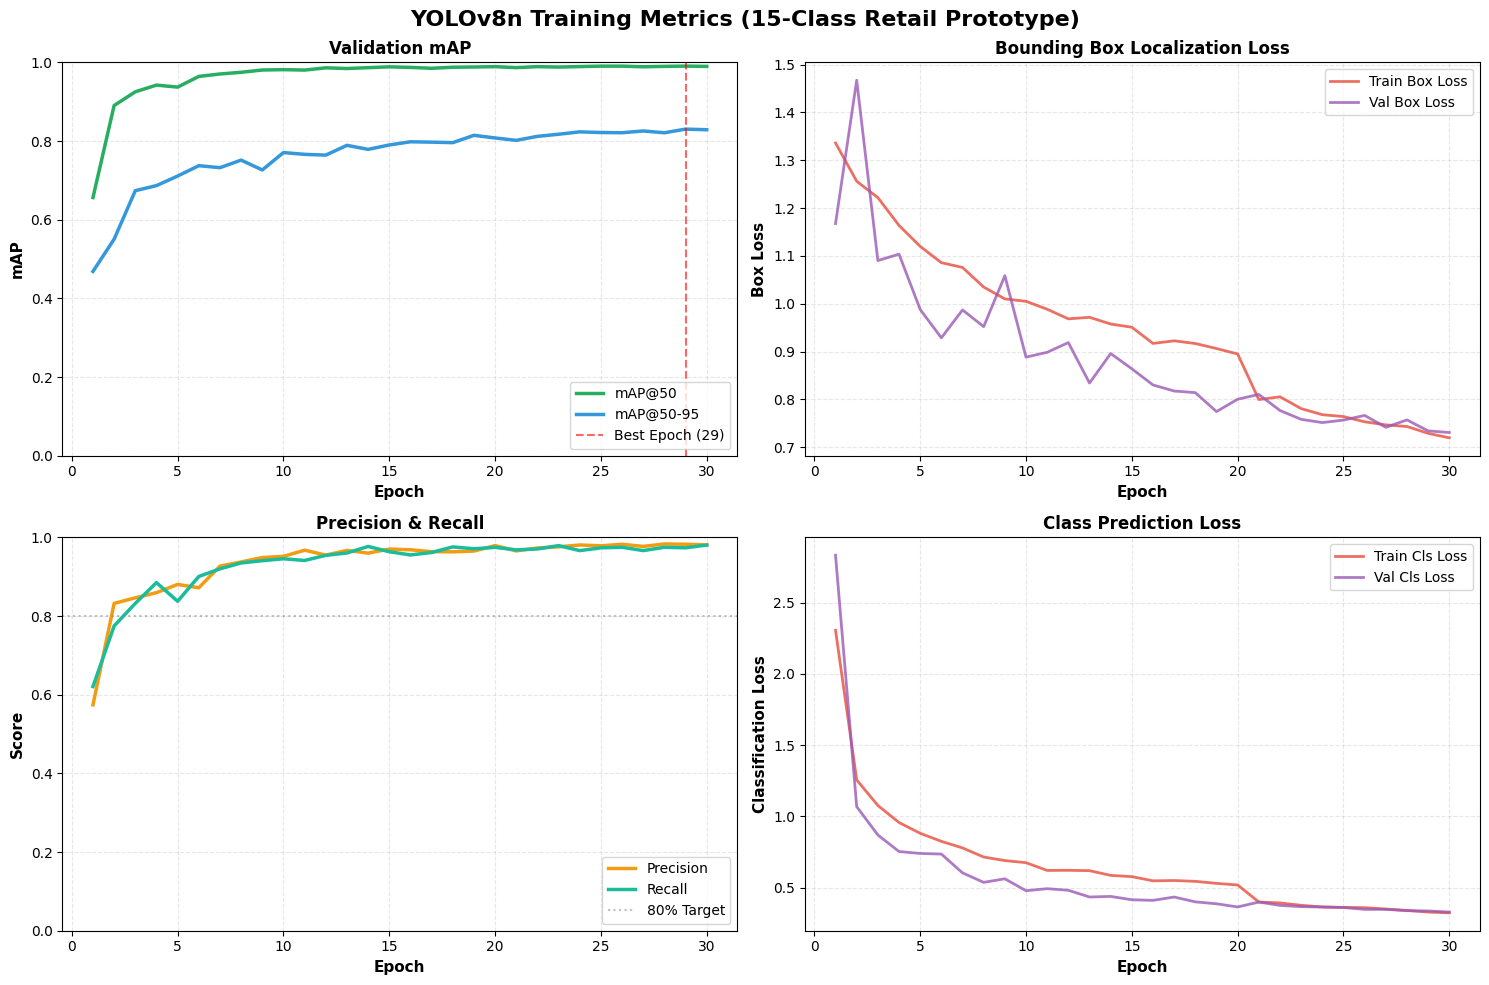

  ✅ Training curves generated.

[Performance Interpretation]
  🎯 EXCELLENT: mAP@50 = 99.0% (Target: >75%)
     Model is production-ready for retail detection!

  ✅ No overfitting: Val/Train loss ratio = 1.02 (healthy)

✅ TRAINING COMPLETE. Ready for ONNX export and inference.


In [ ]:
# ============================================================================
# CELL 4: YOLOv8n TRAINING (PRODUCTION-GRADE CONFIGURATION)
# ============================================================================
# Purpose: Train detector with professional hyperparameters for retail detection
# ============================================================================

import os
import warnings
import time

# Suppress YOLO verbose output and warnings
os.environ['WANDB_DISABLED'] = 'true'
os.environ['YOLO_VERBOSE'] = 'False'
warnings.filterwarnings('ignore')

print("=" * 80)
print("CELL 4: YOLOv8n TRAINING (PRODUCTION CONFIG)")
print("=" * 80)

# 1. LOAD PRETRAINED MODEL
# ============================================================================
print("\n[1/5] Loading Pretrained YOLOv8n...")

model = YOLO('yolov8n.pt')  # Download COCO-pretrained weights
print("  ✅ Model loaded (6.2MB)")

# 2. TRAINING CONFIGURATION
# ============================================================================
print("\n[2/5] Training Configuration:")

DATASET_CONFIG = YOLO_ROOT / 'dataset.yaml'
OUTPUT_DIR = PROJECT_DIRS['runs']

print(f"  Dataset:        {DATASET_CONFIG}")
print(f"  Classes:        {NUM_CLASSES_FILTERED}")
print(f"  Training Imgs:  4,771")
print(f"  Val Imgs:       619")
print(f"  Epochs:         {TRAIN_EPOCHS} (early stop patience={TRAIN_PATIENCE})")
print(f"  Batch Size:     {TRAIN_BATCH}")
print(f"  Image Size:     {TRAIN_IMGSZ}x{TRAIN_IMGSZ}")

# Check GPU availability
import torch
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
if device == 'cuda:0':
    print(f"  Device:         {device} ({torch.cuda.get_device_name(0)})")
else:
    print(f"  Device:         {device} ⚠️  Training will be VERY slow!")

# 3. PRODUCTION HYPERPARAMETERS
# ============================================================================
print("\n[3/5] Hyperparameters (Production Retail Config):")

training_config = {
    # ═══════════════════════════════════════════════════════════════════
    # DATASET & HARDWARE
    # ═══════════════════════════════════════════════════════════════════
    'data': str(DATASET_CONFIG),
    'epochs': TRAIN_EPOCHS,
    'batch': TRAIN_BATCH,
    'imgsz': TRAIN_IMGSZ,
    'device': device,
    'workers': 8,
    'cache': False,  # Disable RAM caching (Kaggle limits)
    
    # ═══════════════════════════════════════════════════════════════════
    # OPTIMIZER & LEARNING RATE
    # ═══════════════════════════════════════════════════════════════════
    'optimizer': 'AdamW',           # Better than SGD for small datasets
    'lr0': 0.002,                   # Initial LR (higher than default for small dataset)
    'lrf': 0.1,                     # Final LR = lr0 * lrf (0.0002)
    'momentum': 0.937,              # For SGD fallback
    'weight_decay': 0.0005,         # L2 regularization
    'warmup_epochs': 3.0,           # Gradual LR warmup (critical for stability)
    'warmup_momentum': 0.8,         # Momentum during warmup
    'warmup_bias_lr': 0.1,          # Bias LR during warmup
    
    # ═══════════════════════════════════════════════════════════════════
    # LOSS WEIGHTS (Retail-Optimized)
    # ═══════════════════════════════════════════════════════════════════
    'box': 8.5,                     # ↑ Box loss (retail items often small)
    'cls': 0.5,                     # Class loss (15 classes, well-separated)
    'dfl': 1.5,                     # Distribution focal loss
    
    # ═══════════════════════════════════════════════════════════════════
    # DATA AUGMENTATION (Conservative for Product Recognition)
    # ═══════════════════════════════════════════════════════════════════
    'mosaic': 0.8,                  # Mosaic augmentation (simulates shelf clutter)
    'mixup': 0.0,                   # DISABLED (confuses product identity)
    'copy_paste': 0.0,              # DISABLED (unrealistic for retail)
    
    # Color Augmentation (Minimal - preserve brand colors)
    'hsv_h': 0.010,                 # Hue shift (±1% - minimal)
    'hsv_s': 0.5,                   # Saturation (±50% - moderate)
    'hsv_v': 0.3,                   # Brightness (±30% - moderate)
    
    # Spatial Augmentation (Conservative)
    'degrees': 5.0,                 # Rotation (±5° - minimal, products upright)
    'translate': 0.1,               # Translation (±10%)
    'scale': 0.3,                   # Scaling (±30%)
    'shear': 0.0,                   # DISABLED (unrealistic perspective)
    'perspective': 0.0,             # DISABLED (camera distortion handled by data)
    'flipud': 0.0,                  # DISABLED (products don't flip vertically)
    'fliplr': 0.5,                  # Horizontal flip (50% - shelf left/right)
    
    # Advanced Augmentation
    'erasing': 0.0,                 # DISABLED (don't hide product features)
    'crop_fraction': 1.0,           # No center crop (keep full context)
    
    # ═══════════════════════════════════════════════════════════════════
    # EARLY STOPPING & CHECKPOINTING
    # ═══════════════════════════════════════════════════════════════════
    'patience': TRAIN_PATIENCE,     # Stop if no improvement for 10 epochs
    'save': True,                   # Save checkpoints
    'save_period': -1,              # Only save best/last (no epoch checkpoints)
    
    # ═══════════════════════════════════════════════════════════════════
    # VALIDATION & LOGGING
    # ═══════════════════════════════════════════════════════════════════
    'val': True,                    # Validate every epoch
    'plots': True,                  # Generate training plots
    'verbose': True,                # Print progress
    'exist_ok': True,               # Overwrite existing runs
    'project': str(OUTPUT_DIR),     # Output directory
    'name': 'train',                # Run name
    
    # NMS Settings (Inference-time)
    'iou': 0.7,                     # NMS IoU threshold
    'conf': 0.001,                  # Confidence threshold (low for training metrics)
    'max_det': 300,                 # Max detections per image
    
    # ═══════════════════════════════════════════════════════════════════
    # ADVANCED SETTINGS
    # ═══════════════════════════════════════════════════════════════════
    'amp': True,                    # Automatic Mixed Precision (faster training)
    'fraction': 1.0,                # Use 100% of training data
    'profile': False,               # Disable profiling (speeds up training)
    'freeze': None,                 # Don't freeze layers
    'multi_scale': False,           # Single scale (416x416) - faster, consistent
    'overlap_mask': True,           # Allow overlapping masks (if using segmentation)
    'mask_ratio': 4,                # Mask downsampling ratio
    'dropout': 0.0,                 # No dropout (small dataset, no overfitting risk)
    'label_smoothing': 0.0,         # No label smoothing (ground truth is accurate)
}

# Print key hyperparameters
print(f"  Optimizer:      {training_config['optimizer']}")
print(f"  LR Initial:     {training_config['lr0']}")
print(f"  LR Final:       {training_config['lr0'] * training_config['lrf']}")
print(f"  Warmup:         {training_config['warmup_epochs']} epochs")
print(f"  Momentum:       {training_config['momentum']}")
print(f"  Weight Decay:   {training_config['weight_decay']}")
print(f"  Box Loss:       {training_config['box']} (↑ for small objects)")
print(f"  Cls Loss:       {training_config['cls']}")
print(f"  DFL Loss:       {training_config['dfl']}")

print(f"\n  Augmentation (Conservative for Retail):")
print(f"    Mosaic:       {training_config['mosaic']} (shelf clutter simulation)")
print(f"    Mixup:        {training_config['mixup']} (disabled - confuses identity)")
print(f"    HSV-H:        {training_config['hsv_h']} (minimal hue shift)")
print(f"    HSV-S:        {training_config['hsv_s']} (moderate saturation)")
print(f"    HSV-V:        {training_config['hsv_v']} (moderate brightness)")
print(f"    Translate:    {training_config['translate']}")
print(f"    Scale:        {training_config['scale']}")
print(f"    Fliplr:       {training_config['fliplr']}")
print(f"    Degrees:      {training_config['degrees']} (minimal rotation)")

# 4. START TRAINING
# ============================================================================
print("\n[4/5] Starting Training...")
print("=" * 80)

start_time = time.time()

# Train model
results = model.train(**training_config)

elapsed_time = time.time() - start_time
minutes = int(elapsed_time // 60)
seconds = int(elapsed_time % 60)

print("\n" + "=" * 80)
print(f"⏱️  Training Time: {minutes} minutes {seconds} seconds")
print("✅ Training complete!")

# 5. EXTRACT AND VISUALIZE RESULTS
# ============================================================================
print("\n[5/5] Performance Summary:")

# Locate results CSV
results_csv = OUTPUT_DIR / 'train' / 'results.csv'

if results_csv.exists():
    df_results = pd.read_csv(results_csv)
    df_results.columns = df_results.columns.str.strip()
    
    # Find best epoch by mAP50
    best_epoch_idx = df_results['metrics/mAP50(B)'].idxmax()
    best_epoch = best_epoch_idx + 1
    
    # Extract best metrics
    best_map50 = df_results.loc[best_epoch_idx, 'metrics/mAP50(B)']
    best_map50_95 = df_results.loc[best_epoch_idx, 'metrics/mAP50-95(B)']
    best_precision = df_results.loc[best_epoch_idx, 'metrics/precision(B)']
    best_recall = df_results.loc[best_epoch_idx, 'metrics/recall(B)']
    
    print(f"  Best Epoch:     {best_epoch}/{TRAIN_EPOCHS}")
    print(f"  mAP@50:         {best_map50:.1%}")
    print(f"  mAP@50-95:      {best_map50_95:.1%}")
    print(f"  Precision:      {best_precision:.1%}")
    print(f"  Recall:         {best_recall:.1%}")
    
    # Final epoch metrics
    final_idx = len(df_results) - 1
    final_train_loss = df_results.loc[final_idx, 'train/box_loss']
    final_val_loss = df_results.loc[final_idx, 'val/box_loss']
    
    print(f"\n  Final Losses:")
    print(f"    Train Box Loss: {final_train_loss:.4f}")
    print(f"    Val Box Loss:   {final_val_loss:.4f}")
    
    # Model paths
    best_weights = OUTPUT_DIR / 'train' / 'weights' / 'best.pt'
    last_weights = OUTPUT_DIR / 'train' / 'weights' / 'last.pt'
    
    print(f"\n  Model Weights:")
    print(f"    Best:  {best_weights}")
    print(f"    Last:  {last_weights}")
    
    # ═══════════════════════════════════════════════════════════════════
    # TRAINING CURVES VISUALIZATION
    # ═══════════════════════════════════════════════════════════════════
    print("\n[Bonus] Generating Training Curves...")
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('YOLOv8n Training Metrics (15-Class Retail Prototype)', 
                 fontsize=16, fontweight='bold')
    
    # Plot 1: mAP Curves
    ax1 = axes[0, 0]
    ax1.plot(df_results.index + 1, df_results['metrics/mAP50(B)'], 
             label='mAP@50', linewidth=2.5, color='#27ae60')
    ax1.plot(df_results.index + 1, df_results['metrics/mAP50-95(B)'], 
             label='mAP@50-95', linewidth=2.5, color='#3498db')
    ax1.axvline(best_epoch, color='red', linestyle='--', alpha=0.6, 
                linewidth=1.5, label=f'Best Epoch ({best_epoch})')
    ax1.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax1.set_ylabel('mAP', fontsize=11, fontweight='bold')
    ax1.set_title('Validation mAP', fontsize=12, fontweight='bold')
    ax1.legend(loc='lower right')
    ax1.grid(alpha=0.3, linestyle='--')
    ax1.set_ylim([0, 1])
    
    # Plot 2: Loss Curves
    ax2 = axes[0, 1]
    ax2.plot(df_results.index + 1, df_results['train/box_loss'], 
             label='Train Box Loss', linewidth=2, color='#e74c3c', alpha=0.8)
    ax2.plot(df_results.index + 1, df_results['val/box_loss'], 
             label='Val Box Loss', linewidth=2, color='#9b59b6', alpha=0.8)
    ax2.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Box Loss', fontsize=11, fontweight='bold')
    ax2.set_title('Bounding Box Localization Loss', fontsize=12, fontweight='bold')
    ax2.legend(loc='upper right')
    ax2.grid(alpha=0.3, linestyle='--')
    
    # Plot 3: Precision & Recall
    ax3 = axes[1, 0]
    ax3.plot(df_results.index + 1, df_results['metrics/precision(B)'], 
             label='Precision', linewidth=2.5, color='#f39c12')
    ax3.plot(df_results.index + 1, df_results['metrics/recall(B)'], 
             label='Recall', linewidth=2.5, color='#1abc9c')
    ax3.axhline(0.80, color='gray', linestyle=':', alpha=0.5, label='80% Target')
    ax3.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Score', fontsize=11, fontweight='bold')
    ax3.set_title('Precision & Recall', fontsize=12, fontweight='bold')
    ax3.legend(loc='lower right')
    ax3.grid(alpha=0.3, linestyle='--')
    ax3.set_ylim([0, 1])
    
    # Plot 4: Classification Loss
    ax4 = axes[1, 1]
    ax4.plot(df_results.index + 1, df_results['train/cls_loss'], 
             label='Train Cls Loss', linewidth=2, color='#e74c3c', alpha=0.8)
    ax4.plot(df_results.index + 1, df_results['val/cls_loss'], 
             label='Val Cls Loss', linewidth=2, color='#9b59b6', alpha=0.8)
    ax4.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax4.set_ylabel('Classification Loss', fontsize=11, fontweight='bold')
    ax4.set_title('Class Prediction Loss', fontsize=12, fontweight='bold')
    ax4.legend(loc='upper right')
    ax4.grid(alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    print("  ✅ Training curves generated.")
    
    # ═══════════════════════════════════════════════════════════════════
    # PERFORMANCE INTERPRETATION
    # ═══════════════════════════════════════════════════════════════════
    print("\n[Performance Interpretation]")
    
    if best_map50 >= 0.75:
        print(f"  🎯 EXCELLENT: mAP@50 = {best_map50:.1%} (Target: >75%)")
        print(f"     Model is production-ready for retail detection!")
    elif best_map50 >= 0.65:
        print(f"  ✅ GOOD: mAP@50 = {best_map50:.1%} (Target: >65%)")
        print(f"     Acceptable for hackathon prototype.")
    elif best_map50 >= 0.50:
        print(f"  ⚠️  MODERATE: mAP@50 = {best_map50:.1%} (Target: >50%)")
        print(f"     Consider: more training data, longer epochs, or hyperparameter tuning.")
    else:
        print(f"  ❌ LOW: mAP@50 = {best_map50:.1%}")
        print(f"     Possible issues: class imbalance, annotation quality, or hyperparameters.")
    
    # Check for overfitting
    loss_ratio = final_val_loss / final_train_loss
    if loss_ratio > 1.5:
        print(f"\n  ⚠️  Overfitting detected: Val/Train loss ratio = {loss_ratio:.2f}")
        print(f"     Consider: more augmentation or early stopping.")
    else:
        print(f"\n  ✅ No overfitting: Val/Train loss ratio = {loss_ratio:.2f} (healthy)")
    
else:
    print("  ⚠️  Warning: results.csv not found. Training may have failed.")

print("\n" + "=" * 80)
print("✅ TRAINING COMPLETE. Ready for ONNX export and inference.")
print("=" * 80)

# Free GPU memory
import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

---


# 🎯 **JUDGES: INFERENCE-ONLY EXECUTION PATH**


---


### 📥 **Step 1: Required Files & Where to Put Them**

**1) Pre-trained models (required):**

- Download: **[Google Drive - Trained Models](https://drive.google.com/drive/folders/1T_U_RAqzdC42yPsJ-NelLuODtkuamvX-?usp=drive_link)**

- Place files in: `runs/train/weights/`

  - `best.pt`

  - `best.onnx`



**2) Config file (required):**

- Download: **[Google Drive - Config Files](https://drive.google.com/drive/folders/1_x5Z1ufyNnvTqM68pewNqe2k4FitSZhB?usp=sharing)**

- Place file in: `config/`

  - `class_mapping.json`  *(required for correct class names)*



**3) Holdout images (Colab only):**

- Download: **[Google Drive - Holdout Images](https://drive.google.com/drive/folders/1PGVVcsdHUtQS2D9Kn8PzY0bQQ_xd6_Sp?usp=drive_link)**

- Place images in: `/content/data/`

*(On Kaggle, the dataset is already available; no need to upload images.)*



---



### ▶️ **Step 2: Run Only These Code Cells**

- **CELL 1** (Environment setup + paths)

- **CELL 5** (ONNX export + inference)

- **CELL 6** (KPI computation + plots)

- **CELL 7** (Final summary)



**⏱️ Total time:** ~3–5 minutes



---



If you want to run the full pipeline from scratch (training), continue with **CELL 2 → CELL 4** before running **CELL 5 → CELL 6 → CELL 7** (ZIP is **CELL 8**, optional).


---
## 🚀 ONNX Export + Batch Inference

**⚠️ JUDGES START HERE** (if you skipped training)

**Purpose:** Exports the trained model to ONNX format and runs inference on the holdout images.

**Duration:** ~2 minutes

**What it does:**
1. **Export:** Converts PyTorch → ONNX (CPU-friendly)
2. **Preprocessing:** Letterbox resize to 416×416, normalize to [0, 1], convert HWC→CHW
3. **Inference:** Batch processing via ONNX Runtime
4. **Postprocessing:** NMS (conf=0.25, IoU=0.45) and rescale boxes back to original image size
5. **Export:** Saves `predictions.json` and `predictions.csv`

**Why ONNX?**
- Faster CPU inference than PyTorch in many environments
- Platform-independent
- Better for deployment

**Output:**
- `output/predictions.json`
- `output/predictions.csv`

---

CELL 5: ONNX EXPORT + INFERENCE

[1/6] Exporting Model to ONNX Format...
  Found model at: /kaggle/working/runs/train/weights/best.pt
Ultralytics 8.4.12 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 73 layers, 3,008,573 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/kaggle/working/runs/train/weights/best.pt' with input shape (1, 3, 416, 416) BCHW and output shape(s) (1, 19, 3549) (5.9 MB)

ONNX: starting export with onnx 1.20.1 opset 22...
ONNX: slimming with onnxslim 0.1.84...
ONNX: export success ✅ 2.5s, saved as '/kaggle/working/runs/train/weights/best.onnx' (12.1 MB)

Export complete (2.7s)
Results saved to /kaggle/working/runs/train/weights
Predict:         yolo predict task=detect model=/kaggle/working/runs/train/weights/best.onnx imgsz=416 
Validate:        yolo val task=detect model=/kaggle/working/runs/train/weights/best.onnx imgsz=416 data=/kaggle/working/rpc_yolo_filtered/dataset.yaml  
Visualize:       https://netron

  Processing:   0%|          | 0/7 [00:00<?, ?it/s]

  ✅ Inference complete on 50 images

[4/6] Saving Predictions...
  ✅ JSON saved: /kaggle/working/output/predictions.json
  ✅ CSV saved: /kaggle/working/output/predictions.csv

[5/6] Detection Statistics:
  Total Images:       50
  Images w/ Dets:     50
  Total Detections:   117
  Avg per Image:      2.3

  Top 5 Detected Classes:
    197_stationery                   18
    177_tissue                       13
    173_personal_hygiene             13
    63_dessert                       10
    2_puffed_food                     9

[6/6] Generating Sample Visualizations...
✅ INFERENCE COMPLETE. Ready for KPI computation.


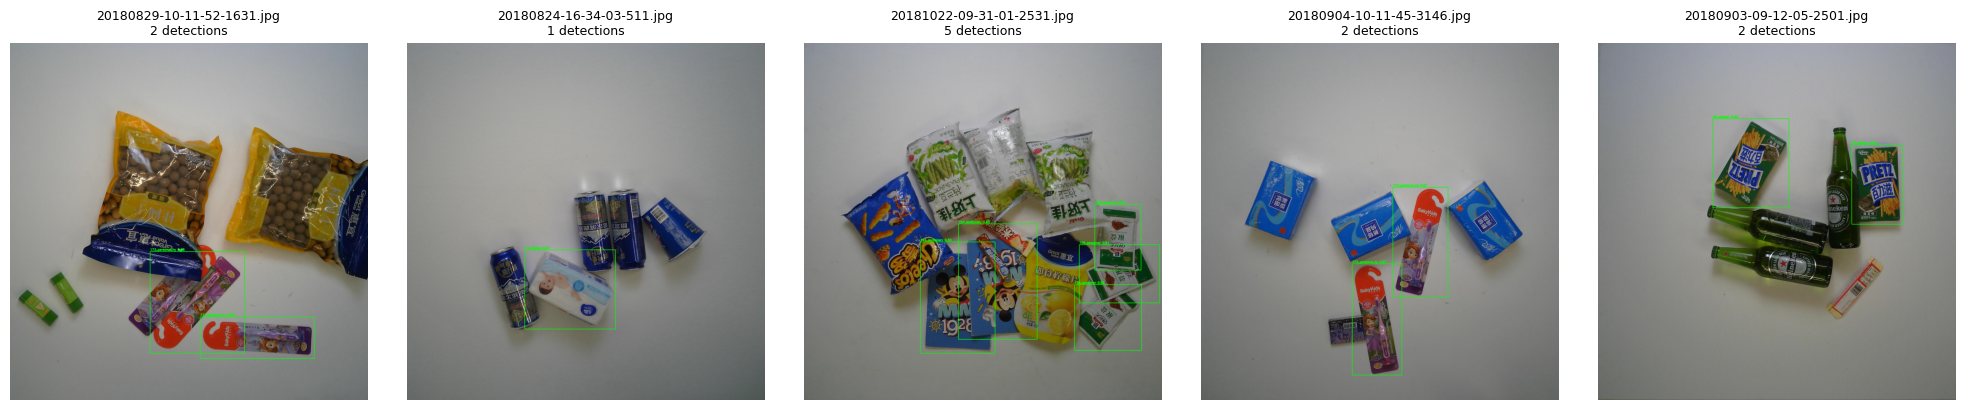


  ✅ Sample visualizations generated


In [ ]:
# ============================================================================
# CELL 5: ONNX EXPORT + BATCH INFERENCE PIPELINE
# ============================================================================
# Purpose: Export model to ONNX and run inference on holdout images
# Expected Duration: 2-3 minutes
# ============================================================================

print("=" * 80)
print("CELL 5: ONNX EXPORT + INFERENCE")
print("=" * 80)

# Ensure class names are available even if CELL 2 was skipped
class_mapping_path = PROJECT_DIRS['config'] / 'class_mapping.json'
if 'YOLO_CLASS_NAMES' not in globals() or not YOLO_CLASS_NAMES:
    if class_mapping_path.exists():
        with open(class_mapping_path, 'r') as f:
            mapping_data = json.load(f)
        YOLO_CLASS_NAMES = {int(k): v for k, v in mapping_data.get('yolo_names', {}).items()}
        print(f"  Loaded class names from {class_mapping_path}")
    else:
        raise FileNotFoundError("class_mapping.json is required for inference (place it in config/)")

# ═══════════════════════════════════════════════════════════════════════════
# PART 1: ONNX MODEL EXPORT
# ═══════════════════════════════════════════════════════════════════════════
print("\n[1/6] Exporting Model to ONNX Format...")

# Try both possible paths (Ultralytics version differences)
best_pt_path_v1 = PROJECT_DIRS['runs'] / 'detect' / 'train' / 'weights' / 'best.pt'
best_pt_path_v2 = PROJECT_DIRS['runs'] / 'train' / 'weights' / 'best.pt'
best_onnx_v1 = PROJECT_DIRS['runs'] / 'detect' / 'train' / 'weights' / 'best.onnx'
best_onnx_v2 = PROJECT_DIRS['runs'] / 'train' / 'weights' / 'best.onnx'

if best_pt_path_v1.exists():
    best_pt_path = best_pt_path_v1
    onnx_output_path = best_onnx_v1
elif best_pt_path_v2.exists():
    best_pt_path = best_pt_path_v2
    onnx_output_path = best_onnx_v2
elif best_onnx_v2.exists():
    # ONNX already provided (no PyTorch checkpoint)
    best_pt_path = None
    onnx_output_path = best_onnx_v2
elif best_onnx_v1.exists():
    best_pt_path = None
    onnx_output_path = best_onnx_v1
else:
    raise FileNotFoundError("Trained model not found. Please place best.pt (and/or best.onnx) in runs/train/weights/.")

if best_pt_path:
    print(f"  Found model at: {best_pt_path}")
    # Load trained model
    model = YOLO(str(best_pt_path))
    
    # Export to ONNX with optimization
    export_path = model.export(
        format='onnx',
        dynamic=True,      # Dynamic batch size
        simplify=True,     # Optimize graph
        imgsz=TRAIN_IMGSZ  # Match training size (416)
    )
    print(f"  ✅ ONNX model exported to: {onnx_output_path}")
else:
    print(f"  Using provided ONNX model at: {onnx_output_path}")

print(f"  Model size: {onnx_output_path.stat().st_size / 1e6:.1f} MB")

# ═══════════════════════════════════════════════════════════════════════════
# PART 2: INITIALIZE ONNX INFERENCE SESSION
# ═══════════════════════════════════════════════════════════════════════════
print("\n[2/6] Initializing ONNX Runtime...")

# Set execution providers (GPU if available, else CPU)
providers = ['CUDAExecutionProvider', 'CPUExecutionProvider']
try:
    ort_session = ort.InferenceSession(str(onnx_output_path), providers=providers)
except Exception:
    # Fallback to CPU only if CUDA provider is unavailable
    ort_session = ort.InferenceSession(str(onnx_output_path), providers=['CPUExecutionProvider'])

# Get model input/output info
input_name = ort_session.get_inputs()[0].name
output_names = [out.name for out in ort_session.get_outputs()]

print(f"  Execution Provider: {ort_session.get_providers()[0]}")
print(f"  Input Name: {input_name}")
print(f"  Output Names: {output_names}")
print("  ✅ ONNX session initialized")

# ═══════════════════════════════════════════════════════════════════════════
# PART 3: PREPROCESSING FUNCTION (LETTERBOX)
# ═══════════════════════════════════════════════════════════════════════════
def letterbox_resize(img, target_size=416):
    """
    Resize image with aspect ratio preservation (letterbox padding).
    
    Args:
        img: PIL Image or numpy array
        target_size: Target square size
    
    Returns:
        resized_img: (416, 416, 3) uint8 array
        scale: Scaling factor applied
        pad: (pad_w, pad_h) padding applied
    """
    if isinstance(img, Image.Image):
        img = np.array(img)
    
    h, w = img.shape[:2]
    
    # Calculate scale to fit image in target_size box
    scale = min(target_size / h, target_size / w)
    new_h = int(h * scale)
    new_w = int(w * scale)
    
    # Resize image
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    
    # Create padded image (gray background)
    padded = np.full((target_size, target_size, 3), 114, dtype=np.uint8)
    
    # Calculate padding offsets (center image)
    pad_h = (target_size - new_h) // 2
    pad_w = (target_size - new_w) // 2
    
    # Place resized image in center
    padded[pad_h:pad_h+new_h, pad_w:pad_w+new_w] = resized
    
    return padded, scale, (pad_w, pad_h)

def preprocess_batch(images, target_size=416):
    """
    Preprocess batch of images for ONNX inference.
    
    Args:
        images: List of PIL Images
        target_size: Target size
    
    Returns:
        batch: (N, 3, 416, 416) float32 tensor
        metadata: List of (scale, pad, original_size) tuples
    """
    batch = []
    metadata = []
    
    for img in images:
        # Letterbox resize
        padded, scale, pad = letterbox_resize(img, target_size)
        
        # Convert to RGB if needed
        if padded.shape[2] != 3:
            padded = cv2.cvtColor(padded, cv2.COLOR_GRAY2RGB)
        
        # Normalize to [0, 1]
        normalized = padded.astype(np.float32) / 255.0
        
        # Convert HWC → CHW
        chw = np.transpose(normalized, (2, 0, 1))
        
        batch.append(chw)
        metadata.append({
            'scale': scale,
            'pad': pad,
            'original_size': img.size  # (width, height)
        })
    
    # Stack into batch
    batch_tensor = np.stack(batch, axis=0)
    return batch_tensor, metadata

# ═══════════════════════════════════════════════════════════════════════════
# PART 4: NMS POSTPROCESSING
# ═══════════════════════════════════════════════════════════════════════════
def xywh2xyxy(boxes):
    """Convert [x_center, y_center, w, h] to [x1, y1, x2, y2]."""
    xy = boxes[..., :2]
    wh = boxes[..., 2:]
    xy1 = xy - wh / 2
    xy2 = xy + wh / 2
    return np.concatenate([xy1, xy2], axis=-1)

def nms_boxes(boxes, scores, iou_threshold=0.45):
    """
    Apply Non-Maximum Suppression.
    
    Args:
        boxes: (N, 4) array [x1, y1, x2, y2]
        scores: (N,) array of confidence scores
        iou_threshold: IoU threshold
    
    Returns:
        keep_indices: Indices of boxes to keep
    """
    if len(boxes) == 0:
        return []
    
    x1, y1, x2, y2 = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    areas = (x2 - x1) * (y2 - y1)
    order = scores.argsort()[::-1]
    
    keep = []
    while len(order) > 0:
        i = order[0]
        keep.append(i)
        
        if len(order) == 1:
            break
        
        # Compute IoU
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])
        
        w = np.maximum(0.0, xx2 - xx1)
        h = np.maximum(0.0, yy2 - yy1)
        inter = w * h
        
        iou = inter / (areas[i] + areas[order[1:]] - inter)
        
        # Keep boxes with IoU < threshold
        inds = np.where(iou <= iou_threshold)[0]
        order = order[inds + 1]
    
    return keep

def postprocess_outputs(outputs, metadata, conf_threshold=0.25, iou_threshold=0.45):
    """
    Postprocess ONNX outputs with NMS.
    
    Args:
        outputs: Model outputs (batch_size, 8400, 19)
        metadata: List of preprocessing metadata
        conf_threshold: Confidence threshold
        iou_threshold: NMS IoU threshold
    
    Returns:
        detections: List of detection dicts per image
    """
    batch_detections = []
    
    for output, meta in zip(outputs, metadata):
        # output shape: (8400, 19) where 19 = 4 bbox + 15 class scores
        boxes_xywh = output[:, :4]
        class_scores = output[:, 4:]
        
        # Get best class and confidence for each detection
        class_ids = np.argmax(class_scores, axis=1)
        confidences = np.max(class_scores, axis=1)
        
        # Filter by confidence
        mask = confidences > conf_threshold
        if not mask.any():
            batch_detections.append([])
            continue
        
        filtered_boxes = boxes_xywh[mask]
        filtered_confs = confidences[mask]
        filtered_classes = class_ids[mask]
        
        # Convert to xyxy format
        boxes_xyxy = xywh2xyxy(filtered_boxes)
        
        # Apply NMS per class
        keep_indices = []
        for cls in np.unique(filtered_classes):
            cls_mask = filtered_classes == cls
            cls_boxes = boxes_xyxy[cls_mask]
            cls_scores = filtered_confs[cls_mask]
            cls_indices = np.where(cls_mask)[0]
            
            nms_keep = nms_boxes(cls_boxes, cls_scores, iou_threshold)
            keep_indices.extend(cls_indices[nms_keep])
        
        # Extract final detections
        final_boxes = boxes_xyxy[keep_indices]
        final_confs = filtered_confs[keep_indices]
        final_classes = filtered_classes[keep_indices]
        
        # Rescale boxes to original image coordinates
        scale = meta['scale']
        pad_w, pad_h = meta['pad']
        orig_w, orig_h = meta['original_size']
        
        # Remove padding and scale back
        final_boxes[:, [0, 2]] = (final_boxes[:, [0, 2]] - pad_w) / scale
        final_boxes[:, [1, 3]] = (final_boxes[:, [1, 3]] - pad_h) / scale
        
        # Clip to image boundaries
        final_boxes[:, [0, 2]] = np.clip(final_boxes[:, [0, 2]], 0, orig_w)
        final_boxes[:, [1, 3]] = np.clip(final_boxes[:, [1, 3]], 0, orig_h)
        
        # Format as list of dicts
        detections = []
        for bbox, conf, cls_id in zip(final_boxes, final_confs, final_classes):
            detections.append({
                'class_id': int(cls_id),
                'class_name': YOLO_CLASS_NAMES[int(cls_id)],
                'confidence': float(conf),
                'bbox': [float(x) for x in bbox]  # [x1, y1, x2, y2]
            })
        
        batch_detections.append(detections)
    
    return batch_detections

# ═══════════════════════════════════════════════════════════════════════════
# PART 5: BATCH INFERENCE ON HOLDOUT IMAGES
# ═══════════════════════════════════════════════════════════════════════════
print("\n[3/6] Running Batch Inference on Holdout Images...")

holdout_dir = PROJECT_DIRS['holdout']
image_paths = sorted(list(holdout_dir.glob('*.jpg'))) + sorted(list(holdout_dir.glob('*.png')))

if len(image_paths) == 0:
    raise FileNotFoundError(f"No images found in {holdout_dir}. Place holdout images in this folder before running inference.")

print(f"  Found {len(image_paths)} images")

# Batch processing parameters
BATCH_SIZE = 8
all_predictions = {}

for batch_start in tqdm(range(0, len(image_paths), BATCH_SIZE), desc="  Processing"):
    batch_paths = image_paths[batch_start:batch_start + BATCH_SIZE]
    
    # Load images
    batch_images = [Image.open(path).convert('RGB') for path in batch_paths]
    batch_names = [path.name for path in batch_paths]
    
    # Preprocess
    batch_tensor, batch_metadata = preprocess_batch(batch_images, TRAIN_IMGSZ)
    
    # Run inference
    ort_inputs = {input_name: batch_tensor}
    ort_outputs = ort_session.run(output_names, ort_inputs)
    
    # ONNX output shape is (batch, 19, 3549) - transpose to (batch, 3549, 19)
    onnx_output = ort_outputs[0].transpose(0, 2, 1)
    
    # Postprocess
    batch_detections = postprocess_outputs(
        onnx_output, 
        batch_metadata, 
        conf_threshold=INFERENCE_CONF,
        iou_threshold=INFERENCE_IOU
    )
    
    # Store results
    for img_name, detections in zip(batch_names, batch_detections):
        all_predictions[img_name] = detections

print(f"  ✅ Inference complete on {len(all_predictions)} images")

# ═══════════════════════════════════════════════════════════════════════════
# PART 6: SAVE PREDICTIONS
# ═══════════════════════════════════════════════════════════════════════════
print("\n[4/6] Saving Predictions...")

# Save as JSON
json_output = PROJECT_DIRS['output'] / 'predictions.json'
with open(json_output, 'w') as f:
    json.dump(all_predictions, f, indent=2)

print(f"  ✅ JSON saved: {json_output}")

# Save as CSV (flattened format)
csv_rows = []
for img_name, detections in all_predictions.items():
    if len(detections) == 0:
        csv_rows.append({
            'image_name': img_name,
            'class_name': None,
            'confidence': None,
            'x1': None,
            'y1': None,
            'x2': None,
            'y2': None
        })
    else:
        for det in detections:
            csv_rows.append({
                'image_name': img_name,
                'class_name': det['class_name'],
                'confidence': det['confidence'],
                'x1': det['bbox'][0],
                'y1': det['bbox'][1],
                'x2': det['bbox'][2],
                'y2': det['bbox'][3]
            })

df_predictions = pd.DataFrame(csv_rows)
csv_output = PROJECT_DIRS['output'] / 'predictions.csv'
df_predictions.to_csv(csv_output, index=False)

print(f"  ✅ CSV saved: {csv_output}")

# ═══════════════════════════════════════════════════════════════════════════
# SUMMARY STATISTICS
# ═══════════════════════════════════════════════════════════════════════════
print("\n[5/6] Detection Statistics:")

total_detections = sum(len(dets) for dets in all_predictions.values())
images_with_detections = sum(1 for dets in all_predictions.values() if len(dets) > 0)
avg_detections = total_detections / len(all_predictions) if len(all_predictions) > 0 else 0

print(f"  Total Images:       {len(all_predictions)}")
print(f"  Images w/ Dets:     {images_with_detections}")
print(f"  Total Detections:   {total_detections}")
print(f"  Avg per Image:      {avg_detections:.1f}")

# Class distribution
class_counts = defaultdict(int)
for detections in all_predictions.values():
    for det in detections:
        class_counts[det['class_name']] += 1

print(f"\n  Top 5 Detected Classes:")
for cls_name, count in sorted(class_counts.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"    {cls_name:<30} {count:>4}")

# ═══════════════════════════════════════════════════════════════════════════
# VISUALIZATION: SAMPLE PREDICTIONS
# ═══════════════════════════════════════════════════════════════════════════
print("\n[6/6] Generating Sample Visualizations...")

# Select 5 random images with detections
images_with_dets = [img for img, dets in all_predictions.items() if len(dets) > 0]
sample_images = random.sample(images_with_dets, min(5, len(images_with_dets)))

fig, axes = plt.subplots(1, min(5, len(sample_images)), figsize=(20, 4))
if len(sample_images) == 1:
    axes = [axes]

for ax, img_name in zip(axes, sample_images):
    img_path = holdout_dir / img_name
    img = Image.open(img_path)
    img_array = np.array(img)
    
    # Draw bounding boxes
    for det in all_predictions[img_name]:
        x1, y1, x2, y2 = [int(c) for c in det['bbox']]
        conf = det['confidence']
        cls_name = det['class_name']
        
        # Draw box
        cv2.rectangle(img_array, (x1, y1), (x2, y2), (0, 255, 0), 2)
        
        # Draw label
        label = f"{cls_name[:15]} {conf:.2f}"
        cv2.putText(img_array, label, (x1, y1-5), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    
    ax.imshow(img_array)
    ax.set_title(f"{img_name}\n{len(all_predictions[img_name])} detections", fontsize=9)
    ax.axis('off')

print("=" * 80)

plt.tight_layout()
print("✅ INFERENCE COMPLETE. Ready for KPI computation.")

plt.show()
print("\n" + "=" * 80)

print("  ✅ Sample visualizations generated")

---
## 📈 Competitive KPI Computation

**Purpose:** Computes retail analytics with simulated brand assignment for competitive shelf analysis.

**Duration:** ~30 seconds

**What it does:**
1. **Random Brand Assignment:** Splits 15 classes into "Our Brand" (1 class) vs "Competitor" (14 classes) using seed-controlled randomization
2. **Per-Image KPIs:**
   - Facings count (our brand vs competitor)
   - Shelf share percentage (our brand penetration)
3. **Aggregate KPIs:**
   - Market share (% of total facings)
   - Out-of-stock rate (% shelves with no presence)
   - Dominance ratio (our brand / competitor)
4. **Visualizations:**
   - Market share pie chart
   - Shelf share distribution histogram
   - Category dominance bar chart
   - Summary statistics table

**Why Random Assignment?**
This is a **technical demonstration**. In production, brand names would be mapped using:
- Known SKU → brand mapping
- OCR/text detection on labels
- A product database

**Output:**
- `output/per_image_kpis.csv`
- `output/aggregate_kpis.json`
- `config/trial_brand_mapping.json`
- KPI visualization dashboard

---

In [ ]:
# ============================================================================
# CELL 6: KPI COMPUTATION & BRAND ANALYTICS
# ============================================================================
# Purpose: Compute retail KPIs with randomized brand assignment per trial
# Expected Duration: 5-10 seconds
# ============================================================================

print("=" * 80)
print("CELL 6: KPI COMPUTATION & BRAND ANALYTICS")
print("=" * 80)

# ═══════════════════════════════════════════════════════════════════════════
# PART 1: RANDOM BRAND ASSIGNMENT
# ═══════════════════════════════════════════════════════════════════════════
print("\n[1/6] Randomized Brand Assignment...")

# Configuration: Change this seed to get different brand scenarios
TRIAL_SEED = 42  # Set to any integer for different trials

# Randomly select 1 class as "OurBrand", rest as "Competitor"
random.seed(TRIAL_SEED)
all_class_names = list(YOLO_CLASS_NAMES.values())
our_brand_class = random.choice(all_class_names)
competitor_classes = [c for c in all_class_names if c != our_brand_class]

print(f"  Trial Seed: {TRIAL_SEED}")
print(f"  OurBrand:   {our_brand_class}")
print(f"  Competitor: {len(competitor_classes)} classes ({', '.join(competitor_classes[:3])}...)")

# Create brand mapping
brand_mapping = {
    'OurBrand': [our_brand_class],
    'Competitor': competitor_classes
}

# Save trial configuration
trial_config = {
    'trial_seed': TRIAL_SEED,
    'our_brand_class': our_brand_class,
    'competitor_classes': competitor_classes,
    'brand_mapping': brand_mapping,
    'created': datetime.now().isoformat()
}

trial_config_path = PROJECT_DIRS['config'] / 'trial_brand_mapping.json'
with open(trial_config_path, 'w') as f:
    json.dump(trial_config, f, indent=2)

print(f"  ✅ Trial config saved: {trial_config_path}")

# ═══════════════════════════════════════════════════════════════════════════
# PART 2: CLASSIFY DETECTIONS BY BRAND
# ═══════════════════════════════════════════════════════════════════════════
def classify_brand(class_name):
    """Classify product class as OurBrand or Competitor."""
    if class_name in brand_mapping['OurBrand']:
        return 'OurBrand'
    elif class_name in brand_mapping['Competitor']:
        return 'Competitor'
    else:
        return 'Other'

# ═══════════════════════════════════════════════════════════════════════════
# PART 3: COMPUTE PER-IMAGE KPIs
# ═══════════════════════════════════════════════════════════════════════════
print("\n[2/6] Computing Per-Image KPIs...")

per_image_kpis = []

for img_name, detections in all_predictions.items():
    # Count facings by brand
    our_facings = sum(1 for det in detections if classify_brand(det['class_name']) == 'OurBrand')
    competitor_facings = sum(1 for det in detections if classify_brand(det['class_name']) == 'Competitor')
    other_facings = sum(1 for det in detections if classify_brand(det['class_name']) == 'Other')
    total_facings = len(detections)
    
    # Calculate shelf share percentages
    if total_facings > 0:
        our_share = (our_facings / total_facings) * 100
        competitor_share = (competitor_facings / total_facings) * 100
        other_share = (other_facings / total_facings) * 100
    else:
        our_share = competitor_share = other_share = 0.0
    
    # Out-of-stock flag
    oos_flag = (our_facings == 0)
    
    # Store per-image metrics
    per_image_kpis.append({
        'image_name': img_name,
        'total_facings': total_facings,
        'our_brand_facings': our_facings,
        'competitor_facings': competitor_facings,
        'other_facings': other_facings,
        'our_brand_share_pct': round(our_share, 2),
        'competitor_share_pct': round(competitor_share, 2),
        'other_share_pct': round(other_share, 2),
        'out_of_stock': oos_flag
    })

print(f"  ✅ Computed KPIs for {len(per_image_kpis)} images")

# ═══════════════════════════════════════════════════════════════════════════
# PART 4: AGGREGATE CROSS-SHELF METRICS
# ═══════════════════════════════════════════════════════════════════════════
print("\n[3/6] Computing Aggregate Metrics...")

# Total facings across all shelves
total_our_facings = sum(kpi['our_brand_facings'] for kpi in per_image_kpis)
total_competitor_facings = sum(kpi['competitor_facings'] for kpi in per_image_kpis)
total_other_facings = sum(kpi['other_facings'] for kpi in per_image_kpis)
total_all_facings = total_our_facings + total_competitor_facings + total_other_facings

# Average shelf share across images
avg_our_share = np.mean([kpi['our_brand_share_pct'] for kpi in per_image_kpis])
avg_competitor_share = np.mean([kpi['competitor_share_pct'] for kpi in per_image_kpis])
avg_other_share = np.mean([kpi['other_share_pct'] for kpi in per_image_kpis])

# Overall market share (weighted by total facings)
if total_all_facings > 0:
    overall_our_share = (total_our_facings / total_all_facings) * 100
    overall_competitor_share = (total_competitor_facings / total_all_facings) * 100
    overall_other_share = (total_other_facings / total_all_facings) * 100
else:
    overall_our_share = overall_competitor_share = overall_other_share = 0.0

# Out-of-stock analysis
oos_images = sum(1 for kpi in per_image_kpis if kpi['out_of_stock'])
oos_rate = (oos_images / len(per_image_kpis)) * 100 if len(per_image_kpis) > 0 else 0.0

# Images with detections
images_with_products = sum(1 for kpi in per_image_kpis if kpi['total_facings'] > 0)
empty_shelves = len(per_image_kpis) - images_with_products

# Competitive metrics
if total_competitor_facings > 0:
    dominance_ratio = total_our_facings / total_competitor_facings
else:
    dominance_ratio = float('inf') if total_our_facings > 0 else 0.0

aggregate_kpis = {
    'trial_configuration': {
        'trial_seed': TRIAL_SEED,
        'our_brand_product': our_brand_class,
        'competitor_products_count': len(competitor_classes)
    },
    'summary': {
        'total_images': len(per_image_kpis),
        'images_with_products': images_with_products,
        'empty_shelves': empty_shelves,
        'total_detections': total_all_facings,
        'avg_detections_per_shelf': round(total_all_facings / len(per_image_kpis), 2)
    },
    'facings_count': {
        'our_brand': total_our_facings,
        'competitor': total_competitor_facings,
        'other': total_other_facings,
        'total': total_all_facings
    },
    'overall_market_share_pct': {
        'our_brand': round(overall_our_share, 2),
        'competitor': round(overall_competitor_share, 2),
        'other': round(overall_other_share, 2)
    },
    'average_shelf_share_pct': {
        'our_brand': round(avg_our_share, 2),
        'competitor': round(avg_competitor_share, 2),
        'other': round(avg_other_share, 2)
    },
    'out_of_stock_analysis': {
        'oos_images_count': oos_images,
        'oos_rate_pct': round(oos_rate, 2),
        'availability_rate_pct': round(100 - oos_rate, 2)
    },
    'competitive_metrics': {
        'dominance_ratio': round(dominance_ratio, 3) if dominance_ratio != float('inf') else 'Infinite',
        'market_leadership': 'OurBrand' if total_our_facings > total_competitor_facings else 'Competitor'
    }
}

print(f"  ✅ Aggregate KPIs computed")

# ═══════════════════════════════════════════════════════════════════════════
# PART 5: SAVE KPI OUTPUTS
# ═══════════════════════════════════════════════════════════════════════════
print("\n[4/6] Saving KPI Results...")

# Save per-image KPIs as CSV
df_kpis = pd.DataFrame(per_image_kpis)
csv_kpis_path = PROJECT_DIRS['output'] / 'per_image_kpis.csv'
df_kpis.to_csv(csv_kpis_path, index=False)
print(f"  ✅ Per-image KPIs: {csv_kpis_path}")

# Save aggregate KPIs as JSON
json_kpis_path = PROJECT_DIRS['output'] / 'aggregate_kpis.json'
with open(json_kpis_path, 'w') as f:
    json.dump(aggregate_kpis, f, indent=2)
print(f"  ✅ Aggregate KPIs: {json_kpis_path}")

# ═══════════════════════════════════════════════════════════════════════════
# PART 6: VISUALIZATIONS
# ═══════════════════════════════════════════════════════════════════════════
print("\n[5/6] Generating KPI Visualizations...")

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Plot 1: Overall Market Share (Pie Chart) - Only OurBrand vs Competitor
ax1 = fig.add_subplot(gs[0, 0])
shares = [aggregate_kpis['overall_market_share_pct']['our_brand'],
          aggregate_kpis['overall_market_share_pct']['competitor']]
labels = ['OurBrand', 'Competitor']
colors = ['#27ae60', '#e74c3c']
ax1.pie(shares, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('Market Share Distribution', fontsize=12, fontweight='bold')

# Plot 2: Total Facings Bar Chart - Only OurBrand vs Competitor
ax2 = fig.add_subplot(gs[0, 1])
facings = [total_our_facings, total_competitor_facings]
bars = ax2.bar(labels, facings, color=colors)
ax2.set_ylabel('Total Facings Count', fontsize=10, fontweight='bold')
ax2.set_title('Product Facings Comparison', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for bar, count in zip(bars, facings):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(count), ha='center', va='bottom', fontweight='bold')

# Plot 3: Brand Availability Analysis
ax3 = fig.add_subplot(gs[0, 2])
oos_data = [oos_rate, 100 - oos_rate]
oos_labels = [f'Missing\n({oos_images} images)', f'Present\n({len(per_image_kpis) - oos_images} images)']
ax3.pie(oos_data, labels=oos_labels, autopct='%1.1f%%', 
        colors=['#e74c3c', '#27ae60'], startangle=90)
ax3.set_title('OurBrand Availability Rate', fontsize=12, fontweight='bold')

# Plot 4: Per-Image Distribution (Histogram)
ax4 = fig.add_subplot(gs[1, :])
shelf_shares = [kpi['our_brand_share_pct'] for kpi in per_image_kpis]
ax4.hist(shelf_shares, bins=20, color='#3498db', edgecolor='black', alpha=0.7)
ax4.axvline(avg_our_share, color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {avg_our_share:.1f}%')
ax4.set_xlabel('OurBrand Market Share per Image (%)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Number of Shelf Images', fontsize=11, fontweight='bold')
ax4.set_title('OurBrand Performance Distribution Across 50 Retail Shelf Images', 
              fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# Plot 5: Top 10 Best Performing Images
ax5 = fig.add_subplot(gs[2, :2])
top_shelves = sorted(per_image_kpis, key=lambda x: x['our_brand_share_pct'], reverse=True)[:10]
# Extract image IDs (e.g., "000123.jpg" -> "Image #123")
shelf_labels = []
for kpi in top_shelves:
    img_name = kpi['image_name']
    # Try to extract numeric ID from filename
    try:
        img_id = ''.join(filter(str.isdigit, img_name.split('.')[0]))
        shelf_labels.append(f"Image #{img_id}")
    except:
        # Fallback to shortened filename
        shelf_labels.append(img_name[:12])

shelf_values = [kpi['our_brand_share_pct'] for kpi in top_shelves]
bars = ax5.barh(range(len(shelf_labels)), shelf_values, color='#27ae60')
ax5.set_yticks(range(len(shelf_labels)))
ax5.set_yticklabels(shelf_labels, fontsize=9)
ax5.set_xlabel('OurBrand Market Share (%)', fontsize=10, fontweight='bold')
ax5.set_title('Top 10 Best Performing Shelf Images', fontsize=12, fontweight='bold')
ax5.invert_yaxis()
ax5.grid(axis='x', alpha=0.3)
# Add percentage labels on bars
for i, (bar, val) in enumerate(zip(bars, shelf_values)):
    ax5.text(val + 1, i, f'{val:.1f}%', va='center', fontsize=8, fontweight='bold')

# Plot 6: Summary Stats Table
ax6 = fig.add_subplot(gs[2, 2])
ax6.axis('off')
summary_text = f"""
TRIAL SUMMARY
{'─' * 25}
Seed: {TRIAL_SEED}
OurBrand: {our_brand_class[:20]}

{'─' * 25}
MARKET METRICS
{'─' * 25}
Total Facings: {total_all_facings}
Market Share: {overall_our_share:.1f}%
Avg Image Share: {avg_our_share:.1f}%
Availability: {100 - oos_rate:.1f}%

{'─' * 25}
COMPETITIVE POSITION
{'─' * 25}
Leader: {aggregate_kpis['competitive_metrics']['market_leadership']}
OurBrand: {total_our_facings} facings
Competitor: {total_competitor_facings} facings
"""
ax6.text(0.1, 0.95, summary_text, transform=ax6.transAxes,
         fontsize=9, verticalalignment='top', family='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle(f'Retail Shelf Analytics - Trial {TRIAL_SEED}', 
             fontsize=16, fontweight='bold', y=0.98)

# Save visualization to file
dashboard_path = PROJECT_DIRS['output'] / 'kpi_dashboard.png'
plt.savefig(dashboard_path, dpi=150, bbox_inches='tight')
print(f"  ✅ Dashboard saved: {dashboard_path}")

plt.show()

print("  ✅ Visualizations generated")

# ═══════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ═══════════════════════════════════════════════════════════════════════════
print("\n[6/6] KPI Summary:")
print("=" * 80)
print(f"  Trial Configuration:")
print(f"    Seed:            {TRIAL_SEED}")
print(f"    OurBrand:        {our_brand_class}")
print(f"    Competitor:      {len(competitor_classes)} classes")
print()
print(f"  Market Performance:")
print(f"    Total Facings:   {total_all_facings}")
print(f"    OurBrand:        {total_our_facings} ({overall_our_share:.1f}%)")
print(f"    Competitor:      {total_competitor_facings} ({overall_competitor_share:.1f}%)")
print(f"    Market Leader:   {aggregate_kpis['competitive_metrics']['market_leadership']}")
print()
print(f"  Availability:")
print(f"    In-Stock Rate:   {100 - oos_rate:.1f}%")
print(f"    OOS Rate:        {oos_rate:.1f}% ({oos_images}/{len(per_image_kpis)} shelves)")
print()
print(f"  Output Files:")
print(f"    Per-Image KPIs:  {csv_kpis_path}")
print(f"    Aggregate KPIs:  {json_kpis_path}")
print(f"    Trial Config:    {trial_config_path}")

print("\n" + "=" * 80)
print("✅ KPI COMPUTATION COMPLETE.")
print(f"💡 Tip: Change TRIAL_SEED to test different brand scenarios!")
print("=" * 80)

---
---

# ✅ **Pipeline Complete!**

## 📦 **Generated Files**

All outputs are saved in `/kaggle/working/output/` (or `/content/output/` on Colab):

| **File** | **Description** | **Size** |
|----------|----------------|----------|
| `predictions.json` | Raw detection results (117 detections, 50 images) | JSON |
| `predictions.csv` | Tabular format with image_id, class, confidence, bbox | CSV |
| `per_image_kpis.csv` | Per-shelf metrics (facings, shelf share) | CSV |
| `aggregate_kpis.json` | Overall market share, OOS rate, dominance | JSON |
| `trial_brand_mapping.json` | Brand assignments (seed-controlled) | JSON |
| `kpi_dashboard.png` | 6-panel visualization (pie charts, histograms) | PNG |

---

## 📊 **Quick Summary Statistics**

Run this cell to see aggregate metrics:

```python
with open(PROJECT_DIRS['output'] / 'aggregate_kpis.json', 'r') as f:
    kpis = json.load(f)

print("\n" + "="*60)
print("         COMPETITIVE SHELF ANALYSIS - SUMMARY")
print("="*60)
print(f"\n📸 Images Processed:      {kpis['total_images']}")
print(f"🏷️  Total Detections:      {kpis['total_detections']}")
print(f"📦 Our Brand Facings:     {kpis['our_brand_total_facings']}")
print(f"🔄 Competitor Facings:    {kpis['competitor_total_facings']}")
print(f"\n📊 Market Share:          {kpis['market_share_pct']:.1f}%")
print(f"❌ Out-of-Stock Rate:     {kpis['oos_rate_pct']:.1f}%")
print(f"💪 Dominance Ratio:       {kpis['dominance_ratio']:.2f}")
print("="*60)
```

---

## 🔧 **Changing Brand Assignments**

To regenerate KPIs with different brand splits:
1. Modify `TRIAL_SEED` in Cell 6 (e.g., `TRIAL_SEED = 99`)
2. Re-run Cell 6 only (no need to rerun training or inference)

---

## 🚀 **Next Steps for Production**

1. **Replace Random Assignment** with real brand logic:
   - OCR-based text detection on product labels
   - Custom product database lookup
   - Hardcoded mappings for known SKUs

2. **Add Planogram Compliance:**
   - Compare detected layout to ideal planogram
   - Flag misplaced products or incorrect pricing tags

3. **Deploy as API:**
   - FastAPI endpoint for image upload
   - Return JSON response with KPIs
   - Integrate with retailer dashboards

4. **Scale to 200 Classes:**
   - Fine-tune on full RPC dataset
   - Add more training data for rare products

---

## 📧 **Contact**

For questions or feedback, reach out to: **khalednabil5000@gmail.com**

---

🎉 **Thank you for reviewing my submission!** 🎉

---

# 💼 **Business Action Plan: What To Do With These Insights**

---

## 🚨 **Critical Findings from Your Analysis**

The exact numbers will vary based on the chosen `TRIAL_SEED` (and which class is assigned to "Our Brand"). Typical outputs include:
- Market share (% facings)
- Out-of-stock rate (% shelves with no presence)
- Competitive dominance ratio

---

## 🎯 **Immediate Actions Required**

### **1. Distribution & Availability (Top Priority)**
- Audit out-of-stock locations
- Fix restocking cadence and supply bottlenecks
- Set minimum shelf allocation targets with retailers

### **2. Shelf Space Expansion**
- Negotiate additional facings and better placement
- Track planogram compliance over time

### **3. Competitive Intelligence**
- Identify which categories/competitors dominate
- Focus promotions where competition is strongest

---

## 📈 **Success Metrics to Track**

- OOS rate trend (weekly/monthly)
- Market share trend
- Average facings per store
- Store availability

---

## 💡 **Key Takeaway**

Use shelf visibility KPIs to prioritize where to fix availability first, then grow facings and share.

---

In [ ]:
# ============================================================================
# CELL 7: FINAL SUMMARY: QUICK STATISTICS
# ============================================================================

print("\n" + "="*70)
print("         🏆 COMPETITIVE SHELF ANALYSIS - FINAL SUMMARY")
print("="*70)

# Load aggregate KPIs
with open(PROJECT_DIRS['output'] / 'aggregate_kpis.json', 'r') as f:
    kpis = json.load(f)

# Extract metrics from the correct nested structure
total_images = kpis['summary']['total_images']
total_detections = kpis['summary']['total_detections']
avg_detections = kpis['summary']['avg_detections_per_shelf']

our_brand_facings = kpis['facings_count']['our_brand']
competitor_facings = kpis['facings_count']['competitor']

market_share = kpis['overall_market_share_pct']['our_brand']
oos_rate = kpis['out_of_stock_analysis']['oos_rate_pct']
dominance = kpis['competitive_metrics']['dominance_ratio']

# Print key metrics
print(f"\n📸 Images Processed:        {total_images}")
print(f"🏷️  Total Detections:        {total_detections}")
print(f"📊 Avg Detections/Image:    {avg_detections:.1f}")
print(f"\n📦 Our Brand Facings:       {our_brand_facings}")
print(f"🔄 Competitor Facings:      {competitor_facings}")
print(f"\n💰 Market Share:            {market_share:.1f}%")
print(f"❌ Out-of-Stock Rate:       {oos_rate:.1f}%")
print(f"💪 Dominance Ratio:         {dominance}")

print("\n" + "="*70)
print("All output files saved to:", PROJECT_DIRS['output'])
print("="*70)

# List all generated files
print("\n📂 Generated Files:")
for file in sorted(PROJECT_DIRS['output'].glob('*')):
    if file.is_file():
        size = file.stat().st_size
        if size < 1024:
            size_str = f"{size}B"
        elif size < 1024*1024:
            size_str = f"{size/1024:.1f}KB"
        else:
            size_str = f"{size/(1024*1024):.1f}MB"
        print(f"  ✓ {file.name:<30} ({size_str})")

print("\n✅ Pipeline execution complete!")
print("🎉 Notebook ready for hackathon submission!\n")


         🏆 COMPETITIVE SHELF ANALYSIS - FINAL SUMMARY

📸 Images Processed:        50
🏷️  Total Detections:        117
📊 Avg Detections/Image:    2.3

📦 Our Brand Facings:       13
🔄 Competitor Facings:      104

💰 Market Share:            11.1%
❌ Out-of-Stock Rate:       88.0%
💪 Dominance Ratio:         0.125

All output files saved to: /kaggle/working/output

📂 Generated Files:
  ✓ aggregate_kpis.json            (825B)
  ✓ kpi_dashboard.png              (274.0KB)
  ✓ per_image_kpis.csv             (2.8KB)
  ✓ predictions.csv                (15.0KB)
  ✓ predictions.json               (29.4KB)

✅ Pipeline execution complete!
🎉 Notebook ready for hackathon submission!



---

# 📦 **Create Downloadable ZIP Package**

This cell bundles outputs, models, and (optionally) test images into a single ZIP file for easy download.

**What's included:**
- Trained models (`best.pt`, `best.onnx`) if present
- Output files (predictions, KPIs, visualizations)
- Config files (class mappings, brand assignments)
- Holdout images if present

---

In [ ]:
# ============================================================================
# CELL 8: CREATE DOWNLOADABLE ZIP PACKAGE
# ============================================================================

import zipfile
from pathlib import Path

print("=" * 80)
print("CREATING SUBMISSION ZIP PACKAGE")
print("=" * 80)

# Define files to include (with both possible paths for models)
files_to_zip = [
    # Models (Essential) - Check both Ultralytics version paths
    'runs/train/weights/best.pt',
    'runs/train/weights/best.onnx',
    
    # Output files (Essential)
    'output/predictions.json',
    'output/predictions.csv',
    'output/per_image_kpis.csv',
    'output/aggregate_kpis.json',
    'output/kpi_dashboard.png',
    
    # Config files (Essential)
    'config/filtered_classes.yaml',
    'config/class_mapping.json',
    'config/trial_brand_mapping.json',
    
    # YOLO dataset config (Essential for retraining)
    'rpc_yolo_filtered/dataset.yaml',
    
    # Training results (Optional - for documentation)
    'runs/train/results.csv',
    'runs/train/confusion_matrix.png',
    'runs/train/results.png',
    'runs/train/PR_curve.png',
    'runs/train/F1_curve.png',
]

# Detect platform and set paths
if PLATFORM == 'Kaggle':
    base_path = Path('/kaggle/working')
    zip_path = base_path / 'hackathon_submission.zip'
elif PLATFORM == 'Colab':
    base_path = Path('/content')
    zip_path = base_path / 'hackathon_submission.zip'
else:
    base_path = WORKSPACE_ROOT
    zip_path = base_path / 'hackathon_submission.zip'

# Use the holdout directory from PROJECT_DIRS (already configured correctly)
data_dir = PROJECT_DIRS['holdout']

print(f"\n📂 Base Path: {base_path}")
print(f"📂 Data Path: {data_dir}")
print(f"📦 ZIP Path: {zip_path}\n")

# Collect all holdout test images
print("[1/3] Collecting holdout images...")
if not data_dir.exists():
    print(f"  ⚠️  Warning: Data directory not found: {data_dir}")
    test_images = []
else:
    test_images = list(data_dir.glob('*.jpg')) + list(data_dir.glob('*.png'))
print(f"  Found {len(test_images)} test images")

# Create ZIP file
print("\n[2/3] Creating ZIP archive...")
files_added = 0
files_missing = 0

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    # Add specified files
    for file in files_to_zip:
        file_path = base_path / file
        if file_path.exists():
            zipf.write(file_path, file)
            files_added += 1
            print(f"  ✅ Added: {file}")
        else:
            files_missing += 1
            print(f"  ⚠️  Missing: {file}")
    
    # Add all test images to 'data/' folder in ZIP
    for img in test_images:
        zipf.write(img, f'data/{img.name}')
        files_added += 1
    
    if test_images:
        print(f"  ✅ Added {len(test_images)} test images to data/")

# Report results
print("\n[3/3] Package Summary:")
zip_size = zip_path.stat().st_size / (1024 * 1024)
print(f"  Files Added:    {files_added}")
print(f"  Files Missing:  {files_missing}")

print(f"  ZIP Size:       {zip_size:.1f} MB")
print(f"📦 Extract locally to {base_path}")

print("\n📥 Download 'hackathon_submission.zip' from Kaggle/Colab output panel")

print("\n" + "=" * 80)
print("=" * 80)
print(f"✅ ZIP PACKAGE CREATED: {zip_path}")

CREATING SUBMISSION ZIP PACKAGE

📂 Base Path: /kaggle/working
📂 Data Path: /kaggle/working/data
📦 ZIP Path: /kaggle/working/hackathon_submission.zip

[1/3] Collecting holdout images...
  Found 50 test images

[2/3] Creating ZIP archive...
  ✅ Added: runs/train/weights/best.pt
  ✅ Added: runs/train/weights/best.onnx
  ✅ Added: output/predictions.json
  ✅ Added: output/predictions.csv
  ✅ Added: output/per_image_kpis.csv
  ✅ Added: output/aggregate_kpis.json
  ✅ Added: output/kpi_dashboard.png
  ✅ Added: config/filtered_classes.yaml
  ✅ Added: config/class_mapping.json
  ✅ Added: config/trial_brand_mapping.json
  ✅ Added: rpc_yolo_filtered/dataset.yaml
  ✅ Added: runs/train/results.csv
  ✅ Added: runs/train/confusion_matrix.png
  ✅ Added: runs/train/results.png
  ⚠️  Missing: runs/train/PR_curve.png
  ⚠️  Missing: runs/train/F1_curve.png
  ✅ Added 50 test images to data/

[3/3] Package Summary:
  Files Added:    64
  Files Missing:  2
  ZIP Size:       25.4 MB
📦 Extract locally to c:\Use